# Hard MoE Regressor (Straight-Through Gumbel-Softmax)

End-to-end hard Mixture-of-Experts (MoE) regressor with straight-through Gumbel-Softmax routing, two-phase grid search, and final comparison to the baseline.

## Imports + load baseline utilities

In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple
import json
import hashlib
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "hard_moe"
CHECKPOINTS_DIR = ARTIFACT_ROOT / "checkpoints"
RESULTS_DIR = ARTIFACT_ROOT / "results"
PLOTS_DIR = ARTIFACT_ROOT / "plots"
HISTORIES_DIR = ARTIFACT_ROOT / "training_histories"
for _p in (CHECKPOINTS_DIR, RESULTS_DIR, PLOTS_DIR, HISTORIES_DIR):
    _p.mkdir(parents=True, exist_ok=True)

from data.constants import TARGET_COL
import data.encode_features as enc
from models.model import TabularRegressor
from models.train import TrainConfig, make_loaders


def _to_tuple(x):
    return tuple(x) if isinstance(x, list) else x


BASELINE_CONFIG_PATH = NOTEBOOK_DIR / "artifacts" / "baseline" / "results" / "config.json"
DEFAULT_BASELINE = {
    "encoder_hidden": (512, 256, 128, 64),
    "head_hidden": (),
    "dropout": 0.1,
    "lr": 3e-3,
    "weight_decay": 1e-4,
    "epochs": 200,
    "batch_size": 256,
    "seed": 0,
    "early_stop": {"patience": 25, "min_delta": 0.0, "restore_best": True},
    "scheduler": {"enabled": True, "mode": "min", "factor": 0.5, "patience": 8, "min_lr": 1e-6, "threshold": 1e-4},
}

BASELINE_CFG = DEFAULT_BASELINE.copy()
if BASELINE_CONFIG_PATH.exists():
    with BASELINE_CONFIG_PATH.open("r") as f:
        loaded = json.load(f)
    BASELINE_CFG.update(loaded)

BASELINE_CFG["encoder_hidden"] = _to_tuple(BASELINE_CFG.get("encoder_hidden", DEFAULT_BASELINE["encoder_hidden"]))
BASELINE_CFG["head_hidden"] = _to_tuple(BASELINE_CFG.get("head_hidden", DEFAULT_BASELINE["head_hidden"]))
BASELINE_CFG["dropout"] = float(BASELINE_CFG.get("dropout", DEFAULT_BASELINE["dropout"]))
BASELINE_CFG["lr"] = float(BASELINE_CFG.get("lr", DEFAULT_BASELINE["lr"]))
BASELINE_CFG["weight_decay"] = float(BASELINE_CFG.get("weight_decay", DEFAULT_BASELINE["weight_decay"]))
BASELINE_CFG["epochs"] = int(BASELINE_CFG.get("epochs", DEFAULT_BASELINE["epochs"]))
BASELINE_CFG["batch_size"] = int(BASELINE_CFG.get("batch_size", DEFAULT_BASELINE["batch_size"]))
BASELINE_CFG["seed"] = int(BASELINE_CFG.get("seed", DEFAULT_BASELINE["seed"]))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"Baseline config path: {BASELINE_CONFIG_PATH}")
print(f"Baseline epochs: {BASELINE_CFG['epochs']} | batch_size: {BASELINE_CFG['batch_size']} | lr: {BASELINE_CFG['lr']}")

Using device: cpu
Baseline config path: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\baseline\results\config.json
Baseline epochs: 200 | batch_size: 256 | lr: 0.003


## Data loading and feature prep

In [2]:
from torch.utils.data import DataLoader, TensorDataset

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "all_features"
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

(
    X_train_np,
    X_val_np,
    X_test_np,
    y_train_np,
    y_val_np,
    y_test_np,
    feature_artifacts,
) = enc.prepare_features(train_df, val_df, test_df)

INPUT_DIM = X_train_np.shape[1]
BATCH_SIZE = int(BASELINE_CFG["batch_size"])

train_loader, val_loader = make_loaders(
    X_train_np,
    y_train_np,
    X_val_np,
    y_val_np,
    batch_size=BATCH_SIZE,
    separate=False,
)

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_np), torch.from_numpy(y_test_np)),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Input dim: {INPUT_DIM}")
print(f"Train/val/test: {X_train_np.shape}, {X_val_np.shape}, {X_test_np.shape}")

Input dim: 12
Train/val/test: (3804, 12), (815, 12), (816, 12)


In [3]:
CONFIG_SNAPSHOT_PATH = RESULTS_DIR / "config_snapshot.json"
CONFIG_SNAPSHOT_PATH.write_text(
    json.dumps(
        {
            "baseline_cfg": BASELINE_CFG,
            "input_dim": INPUT_DIM,
            "batch_size": BATCH_SIZE,
            "device": str(DEVICE),
        },
        indent=2,
        default=str,
    )
)
print(f"Saved config snapshot to: {CONFIG_SNAPSHOT_PATH}")

Saved config snapshot to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\results\config_snapshot.json


## HardMoERegressor

In [4]:
class GateNet(nn.Module):
    def __init__(self, input_dim: int, num_experts: int, hidden_dims: Tuple[int, ...] = (128, 64), dropout: float = 0.1):
        super().__init__()
        layers = []
        dims = [input_dim, *hidden_dims]
        if hidden_dims:
            for d_in, d_out in zip(dims[:-1], dims[1:]):
                layers.append(nn.Linear(d_in, d_out))
                layers.append(nn.ReLU())
                if dropout and dropout > 0:
                    layers.append(nn.Dropout(dropout))
            layers.append(nn.Linear(dims[-1], num_experts))
        else:
            layers.append(nn.Linear(input_dim, num_experts))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class HardMoERegressor(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_experts: int,
        expert_hidden: Tuple[int, ...],
        dropout: float,
        gate_hidden: Tuple[int, ...] = (128, 64),
    ):
        super().__init__()
        self.num_experts = num_experts
        self.gate = GateNet(input_dim, num_experts, hidden_dims=gate_hidden, dropout=dropout)
        self.experts = nn.ModuleList(
            [
                TabularRegressor(
                    mode="shared",
                    input_dim=input_dim,
                    encoder_hidden=expert_hidden,
                    head_hidden=(),
                    dropout=dropout,
                    output_dim=1,
                )
                for _ in range(num_experts)
            ]
        )

    def forward(self, x: torch.Tensor, tau: float, use_gumbel: bool = True) -> Dict[str, torch.Tensor]:
        logits = self.gate(x)
        if use_gumbel and self.training:
            g_hard = F.gumbel_softmax(logits, tau=tau, hard=True)
        else:
            hard_idx = torch.argmax(logits, dim=1)
            g_hard = F.one_hot(hard_idx, num_classes=self.num_experts).float()
        p = torch.softmax(logits / tau, dim=1)

        y_all = torch.stack([expert(x) for expert in self.experts], dim=1)
        y_hat = (g_hard * y_all).sum(dim=1)

        return {
            "y_hat": y_hat,
            "y_all": y_all,
            "gate_logits": logits,
            "g_hard": g_hard,
            "p": p,
        }

## Training and evaluation helpers

In [5]:
# =========================
# CELL 5 (UPDATED / FIXED)
# =========================

@dataclass
class EarlyStopConfig:
    patience: int = 25
    min_delta: float = 0.0
    restore_best: bool = True


@dataclass
class SchedConfig:
    enabled: bool = True
    mode: str = "min"
    factor: float = 0.5
    patience: int = 8
    min_lr: float = 1e-6
    threshold: float = 1e-4


class EarlyStopping:
    def __init__(self, cfg: EarlyStopConfig):
        self.cfg = cfg
        self.best = None
        self.bad = 0

    def step(self, value: float) -> bool:
        if self.best is None or value < (self.best - self.cfg.min_delta):
            self.best = value
            self.bad = 0
            return False
        self.bad += 1
        return self.bad >= self.cfg.patience


def set_deterministic_seed(seed: int) -> None:
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


def build_optimizer(model: nn.Module, lr: float, weight_decay: float) -> torch.optim.Optimizer:
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)


def build_scheduler(optimizer: torch.optim.Optimizer, cfg: SchedConfig | None):
    if cfg is None or not cfg.enabled:
        return None
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=cfg.mode,
        factor=cfg.factor,
        patience=cfg.patience,
        min_lr=cfg.min_lr,
        threshold=cfg.threshold,
    )


def _usage_and_entropy(p: torch.Tensor, g_hard: torch.Tensor, eps: float = 1e-9):
    entropy = -(p * torch.log(p + eps)).sum(dim=1).mean()
    usage_soft = p.sum(dim=0)
    usage_hard = g_hard.sum(dim=0)
    return entropy, usage_soft, usage_hard


def run_moe_epoch(
    model: HardMoERegressor,
    loader,
    tau: float,
    entropy_weight: float,
    lambda_balance: float,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None = None,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    loss_fn = nn.MSELoss()

    total_loss = 0.0
    total_mse = 0.0
    total_mae = 0.0
    total_entropy = 0.0
    total_balance = 0.0
    usage_soft_sum = None
    usage_hard_sum = None
    n_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        out = model(xb, tau=tau, use_gumbel=is_train)
        y_hat = out["y_hat"]
        p = out["p"]
        g_hard = out["g_hard"]

        task_loss = loss_fn(y_hat, yb)
        entropy, usage_soft, usage_hard = _usage_and_entropy(p, g_hard)
        usage_soft_mean = usage_soft / float(yb.shape[0])
        balance = ((usage_soft_mean - (1.0 / model.num_experts)) ** 2).sum()

        loss = task_loss + (lambda_balance * balance) - (entropy_weight * entropy)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        batch_size = yb.shape[0]
        n_samples += batch_size
        total_loss += loss.item() * batch_size
        total_mse += torch.mean((y_hat - yb) ** 2).item() * batch_size
        total_mae += torch.mean(torch.abs(y_hat - yb)).item() * batch_size
        total_entropy += entropy.item() * batch_size
        total_balance += balance.item() * batch_size

        if usage_soft_sum is None:
            usage_soft_sum = usage_soft.detach().clone()
            usage_hard_sum = usage_hard.detach().clone()
        else:
            usage_soft_sum += usage_soft.detach()
            usage_hard_sum += usage_hard.detach()

    usage_soft_mean = (usage_soft_sum / max(n_samples, 1)).cpu().numpy()
    usage_hard_mean = (usage_hard_sum / max(n_samples, 1)).cpu().numpy()

    return {
        "loss": total_loss / max(n_samples, 1),
        "mse": total_mse / max(n_samples, 1),
        "mae": total_mae / max(n_samples, 1),
        "entropy": total_entropy / max(n_samples, 1),
        "balance": total_balance / max(n_samples, 1),
        "usage_soft": usage_soft_mean,
        "usage_hard": usage_hard_mean,
        "usage_soft_min": float(np.min(usage_soft_mean)),
        "usage_hard_min": float(np.min(usage_hard_mean)),
    }


def run_baseline_epoch(
    model: TabularRegressor,
    loader,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None = None,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    loss_fn = nn.MSELoss()

    total_loss = 0.0
    total_mse = 0.0
    total_mae = 0.0
    n_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)
        loss = loss_fn(pred, yb)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        batch_size = yb.shape[0]
        n_samples += batch_size
        total_loss += loss.item() * batch_size
        total_mse += torch.mean((pred - yb) ** 2).item() * batch_size
        total_mae += torch.mean(torch.abs(pred - yb)).item() * batch_size

    return {
        "loss": total_loss / max(n_samples, 1),
        "mse": total_mse / max(n_samples, 1),
        "mae": total_mae / max(n_samples, 1),
    }


def train_moe(
    num_experts: int,
    tau: float,
    entropy_weight: float,
    lambda_balance: float,
    seed: int,
    max_epochs: int,
    early_stop_cfg: EarlyStopConfig | None = None,
    sched_cfg: SchedConfig | None = None,
):
    set_deterministic_seed(seed)

    model = HardMoERegressor(
        input_dim=INPUT_DIM,
        num_experts=num_experts,
        expert_hidden=BASELINE_CFG["encoder_hidden"],
        dropout=BASELINE_CFG["dropout"],
        gate_hidden=(128, 64),
    ).to(DEVICE)

    optimizer = build_optimizer(model, BASELINE_CFG["lr"], BASELINE_CFG["weight_decay"])
    scheduler = build_scheduler(optimizer, sched_cfg)
    stopper = EarlyStopping(early_stop_cfg) if early_stop_cfg else None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mse": [],
        "val_mse": [],
        "train_mae": [],
        "val_mae": [],
        "train_entropy": [],
        "val_entropy": [],
        "train_balance": [],
        "val_balance": [],
        "train_usage_soft": [],
        "train_usage_hard": [],
        "val_usage_soft": [],
        "val_usage_hard": [],
        "val_usage_soft_min": [],
        "val_usage_hard_min": [],
    }

    best_state = None
    best_val = None
    best_epoch = None

    for epoch in range(1, max_epochs + 1):
        train_metrics = run_moe_epoch(
            model,
            train_loader,
            tau=tau,
            entropy_weight=entropy_weight,
            lambda_balance=lambda_balance,
            device=DEVICE,
            optimizer=optimizer,
        )
        val_metrics = run_moe_epoch(
            model,
            val_loader,
            tau=tau,
            entropy_weight=entropy_weight,
            lambda_balance=lambda_balance,
            device=DEVICE,
            optimizer=None,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_mse"].append(train_metrics["mse"])
        history["val_mse"].append(val_metrics["mse"])
        history["train_mae"].append(train_metrics["mae"])
        history["val_mae"].append(val_metrics["mae"])
        history["train_entropy"].append(train_metrics["entropy"])
        history["val_entropy"].append(val_metrics["entropy"])
        history["train_balance"].append(train_metrics["balance"])
        history["val_balance"].append(val_metrics["balance"])
        history["train_usage_soft"].append(train_metrics["usage_soft"])
        history["train_usage_hard"].append(train_metrics["usage_hard"])
        history["val_usage_soft"].append(val_metrics["usage_soft"])
        history["val_usage_hard"].append(val_metrics["usage_hard"])
        history["val_usage_soft_min"].append(val_metrics["usage_soft_min"])
        history["val_usage_hard_min"].append(val_metrics["usage_hard_min"])

        current_val = val_metrics["mse"]
        if best_val is None or current_val < best_val:
            best_val = current_val
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if scheduler is not None:
            scheduler.step(val_metrics["mse"])

        if stopper and stopper.step(val_metrics["mse"]):
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.best_epoch = best_epoch
    model.best_metric = best_val
    return model, history


def train_baseline(
    seed: int,
    max_epochs: int,
    early_stop_cfg: EarlyStopConfig | None = None,
    sched_cfg: SchedConfig | None = None,
):
    set_deterministic_seed(seed)

    model = TabularRegressor(
        mode="shared",
        input_dim=INPUT_DIM,
        encoder_hidden=BASELINE_CFG["encoder_hidden"],
        head_hidden=BASELINE_CFG["head_hidden"],
        dropout=BASELINE_CFG["dropout"],
        output_dim=1,
    ).to(DEVICE)

    optimizer = build_optimizer(model, BASELINE_CFG["lr"], BASELINE_CFG["weight_decay"])
    scheduler = build_scheduler(optimizer, sched_cfg)
    stopper = EarlyStopping(early_stop_cfg) if early_stop_cfg else None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mse": [],
        "val_mse": [],
        "train_mae": [],
        "val_mae": [],
    }

    best_state = None
    best_val = None
    best_epoch = None

    for epoch in range(1, max_epochs + 1):
        train_metrics = run_baseline_epoch(model, train_loader, device=DEVICE, optimizer=optimizer)
        val_metrics = run_baseline_epoch(model, val_loader, device=DEVICE, optimizer=None)

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_mse"].append(train_metrics["mse"])
        history["val_mse"].append(val_metrics["mse"])
        history["train_mae"].append(train_metrics["mae"])
        history["val_mae"].append(val_metrics["mae"])

        current_val = val_metrics["mse"]
        if best_val is None or current_val < best_val:
            best_val = current_val
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if scheduler is not None:
            scheduler.step(val_metrics["mse"])

        if stopper and stopper.step(val_metrics["mse"]):
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.best_epoch = best_epoch
    model.best_metric = best_val
    return model, history


def evaluate_moe(model: HardMoERegressor, loader, tau: float):
    metrics = run_moe_epoch(
        model,
        loader,
        tau=tau,
        entropy_weight=0.0,
        lambda_balance=0.0,
        device=DEVICE,
        optimizer=None,
    )
    return metrics


def evaluate_baseline(model: TabularRegressor, loader):
    metrics = run_baseline_epoch(model, loader, device=DEVICE, optimizer=None)
    return metrics


def collect_moe_usage(model: HardMoERegressor, loader, tau: float):
    metrics = run_moe_epoch(
        model,
        loader,
        tau=tau,
        entropy_weight=0.0,
        lambda_balance=0.0,
        device=DEVICE,
        optimizer=None,
    )
    return metrics["usage_soft"], metrics["usage_hard"]


@torch.no_grad()
def val_hard_usage_full_dataset(
    model: HardMoERegressor,
    loader,
    device: torch.device,
) -> Dict[str, object]:
    """
    Runs the *entire* val set through the gate in eval mode and computes
    hard routing usage fractions per expert using argmax(logits).
    """
    model.eval()
    E = model.num_experts
    counts = torch.zeros(E, dtype=torch.long)

    total = 0
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model.gate(xb)                  # [B, E]
        hard_idx = torch.argmax(logits, dim=1)   # [B]
        counts += torch.bincount(hard_idx.cpu(), minlength=E)
        total += xb.size(0)

    usage = (counts.float() / max(total, 1)).cpu().numpy()
    return {
        "total": int(total),
        "counts": counts.cpu().numpy(),
        "usage": usage,
        "min_usage": float(np.min(usage)),
    }


## Phase A grid search (coarse, fast)

In [6]:
# =========================
# CELL 6 (PHASE A UPDATED)
# =========================

import itertools
import time

# NUM_EXPERTS_GRID = [2, 3, 4]
# #TAU_GRID = [0.5,1 ,2, 2.5, 3, 5]
# TAU_GRID =  [12.5]

# #ENTROPY_WEIGHT_GRID = [0.0, 0.001, 0.01, 0.05, 0.1]
# ENTROPY_WEIGHT_GRID = [ 1000, 0.05]

# #LAMBDA_BALANCE_RGID = [0.0, 0.05, 0.1, 0.5, 1.0]
# LAMBDA_BALANCE_GRID = [ 5, 0.5]

RUNS_E2_20 = [
    # --- anchor around your best: tau=12.5, ent=2000 ---
    (2, 12.5, 2000,  0.2),
    (2, 12.5, 2000,  0.5),
    (2, 12.5, 2000,  1.0),
    (2, 12.5, 2000,  2.0),
    (2, 12.5, 2000,  5.0),
    (2, 12.5, 2000, 10.0),
    (2, 12.5, 2000, 20.0),

    # --- tau=20 with ent=2000 (you saw good hard balance here) ---
    (2, 20.0, 2000,  0.5),
    (2, 20.0, 2000,  2.0),
    (2, 20.0, 2000, 10.0),

    # --- tau sweep with same ent/balance to see stability ---
    (2,  8.0, 2000,  0.5),
    (2, 16.0, 2000,  0.5),
    (2, 30.0, 2000,  0.5),

    # --- entropy sweep around 2000 (keep lambda moderate) ---
    (2, 12.5, 1500,  2.0),
    (2, 12.5, 3000,  2.0),
    (2, 12.5, 4000,  2.0),

    # --- entropy sweep with stronger balance (push hard usage to be less skewed) ---
    (2, 12.5, 1500, 10.0),
    (2, 12.5, 3000, 10.0),
    (2, 20.0, 3000, 10.0),

    # --- “lower entropy” controls that still looked decent in your results ---
    (2,  8.0, 1000,  0.5),
]

RUNS_E3_20 = [
    # --- baseline band (moderate balance) ---
    (3, 12.5, 2000,  2.0),
    (3, 12.5, 3000,  2.0),
    (3, 12.5, 4000,  2.0),
    (3, 20.0, 2000,  2.0),
    (3, 20.0, 3000,  2.0),
    (3, 20.0, 4000,  2.0),

    # --- stronger balance to fight hard-collapse ---
    (3, 12.5, 2000,  5.0),
    (3, 12.5, 3000,  5.0),
    (3, 12.5, 4000,  5.0),
    (3, 20.0, 2000,  5.0),
    (3, 20.0, 3000,  5.0),
    (3, 20.0, 4000,  5.0),

    # --- push entropy higher (E=3 often needs it) ---
    (3, 12.5, 6000,  5.0),
    (3, 20.0, 6000,  5.0),
    (3, 12.5, 8000, 10.0),
    (3, 20.0, 8000, 10.0),

    # --- tau sweep (with a decent regularization setting) ---
    (3,  8.0, 4000,  5.0),
    (3, 16.0, 4000,  5.0),
    (3, 30.0, 4000,  5.0),

    # --- one “low reg” control (expect collapse, but good to confirm) ---
    (3, 12.5, 1000,  0.5),
]


PHASE_A_EPOCHS = max(50, int(BASELINE_CFG["epochs"] * 0.2))
PHASE_A_SEEDS = [BASELINE_CFG["seed"]]
PHASE_A_EARLY_STOP = EarlyStopConfig(patience=30, min_delta=0.0, restore_best=True)
PHASE_A_SCHED = SchedConfig(enabled=False)
TOP_K = 8

phase_a_results = []

#grid = list(itertools.product(NUM_EXPERTS_GRID, TAU_GRID, ENTROPY_WEIGHT_GRID, LAMBDA_BALANCE_GRID))
grid = RUNS_E2_20 + RUNS_E3_20
total = len(grid)  # should be 375

t0 = time.time()

for i, (num_experts, tau, ent_w, lam_bal) in enumerate(grid, start=1):
    seed = PHASE_A_SEEDS[0]

    model, history = train_moe(
        num_experts=num_experts,
        tau=tau,
        entropy_weight=ent_w,
        lambda_balance=lam_bal,
        seed=seed,
        max_epochs=PHASE_A_EPOCHS,
        early_stop_cfg=PHASE_A_EARLY_STOP,
        sched_cfg=PHASE_A_SCHED,
    )

    best_idx = int(np.argmin(history["val_mse"]))
    best_val_mse = float(history["val_mse"][best_idx])
    best_val_mae = float(history["val_mae"][best_idx])
    mean_entropy = float(np.mean(history["val_entropy"]))

    # NEW: compute HARD usage over the *entire* validation set (argmax routing)
    usage_info = val_hard_usage_full_dataset(model, val_loader, device=DEVICE)
    print("VAL HARD COUNTS:", usage_info["counts"], "TOTAL:", usage_info["total"])
    print("VAL HARD USAGE :", usage_info["usage"], "MIN:", usage_info["min_usage"])

    min_usage_hard_full = float(usage_info["min_usage"])
    usage_hard_full = usage_info["usage"]

    phase_a_results.append(
        {
            "num_experts": num_experts,
            "tau": tau,
            "entropy_weight": ent_w,
            "lambda_balance": lam_bal,
            "seed": seed,
            "best_val_mse": best_val_mse,
            "best_val_mae": best_val_mae,
            "mean_val_entropy": mean_entropy,
            "min_usage_hard_full": min_usage_hard_full,
            "usage_hard_full": usage_hard_full.tolist(),
        }
    )

    collapsed = (min_usage_hard_full < 0.05)
    elapsed_min = (time.time() - t0) / 60.0

    print(
        f"[{i:03d}/{total}] "
        f"E={num_experts} tau={tau:g} entW={ent_w:g} lamB={lam_bal:g} | "
        f"bestMSE={best_val_mse:.6f} bestMAE={best_val_mae:.6f} "
        f"meanEnt={mean_entropy:.4f} "
        f"minUhard(full)={min_usage_hard_full:.3f} "
        f"{'COLLAPSED' if collapsed else 'OK'} | "
        f"elapsed={elapsed_min:.1f}m"
    )

phase_a_df = pd.DataFrame(phase_a_results)
phase_a_path = RESULTS_DIR / "phase_a_results.csv"
phase_a_df.to_csv(phase_a_path, index=False)

# Filter configs where the least-used expert gets <5% of the *full val* samples
collapse_mask = phase_a_df["min_usage_hard_full"] < 0.05
phase_a_ranked = phase_a_df.loc[~collapse_mask].sort_values("best_val_mse")
phase_a_topk = phase_a_ranked.head(TOP_K).reset_index(drop=True)

print(f"\nPhase A results saved to: {phase_a_path}")
print("Top-K configs (Phase A) [after full-val hard-usage filter]:")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(phase_a_topk)


VAL HARD COUNTS: [126 689] TOTAL: 815
VAL HARD USAGE : [0.15460123 0.8453988 ] MIN: 0.15460123121738434
[001/40] E=2 tau=12.5 entW=2000 lamB=0.2 | bestMSE=1.049079 bestMAE=0.743866 meanEnt=0.6931 minUhard(full)=0.155 OK | elapsed=0.4m
VAL HARD COUNTS: [130 685] TOTAL: 815
VAL HARD USAGE : [0.1595092 0.8404908] MIN: 0.15950919687747955
[002/40] E=2 tau=12.5 entW=2000 lamB=0.5 | bestMSE=1.053754 bestMAE=0.743355 meanEnt=0.6931 minUhard(full)=0.160 OK | elapsed=0.7m
VAL HARD COUNTS: [123 692] TOTAL: 815
VAL HARD USAGE : [0.15092024 0.8490797 ] MIN: 0.15092024207115173
[003/40] E=2 tau=12.5 entW=2000 lamB=1 | bestMSE=1.053322 bestMAE=0.746199 meanEnt=0.6931 minUhard(full)=0.151 OK | elapsed=1.4m
VAL HARD COUNTS: [124 691] TOTAL: 815
VAL HARD USAGE : [0.15214723 0.84785277] MIN: 0.15214723348617554
[004/40] E=2 tau=12.5 entW=2000 lamB=2 | bestMSE=1.055258 bestMAE=0.746163 meanEnt=0.6931 minUhard(full)=0.152 OK | elapsed=1.8m
VAL HARD COUNTS: [115 700] TOTAL: 815
VAL HARD USAGE : [0.1411043 

,num_experts,tau,entropy_weight,lambda_balance,seed,best_val_mse,best_val_mae,mean_val_entropy,min_usage_hard_full,usage_hard_full
0,2,12.5,2000,0.2,0,1.049079,0.743866,0.693147,0.154601,"[0.15460123121738434, 0.8453987836837769]"
1,2,12.5,1500,2.0,0,1.050545,0.745773,0.693147,0.142331,"[0.1423312872648239, 0.8576686978340149]"
2,2,20.0,3000,10.0,0,1.052615,0.746713,0.693147,0.082209,"[0.08220858871936798, 0.9177914261817932]"
3,2,12.5,2000,10.0,0,1.053155,0.746760,0.693147,0.060123,"[0.06012269854545593, 0.9398772716522217]"
4,2,12.5,2000,1.0,0,1.053322,0.746199,0.693147,0.150920,"[0.15092024207115173, 0.8490797281265259]"
5,2,12.5,2000,0.5,0,1.053754,0.743355,0.693147,0.159509,"[0.15950919687747955, 0.8404908180236816]"
6,2,12.5,2000,2.0,0,1.055258,0.746163,0.693147,0.152147,"[0.15214723348617554, 0.8478527665138245]"
7,2,12.5,2000,5.0,0,1.055854,0.748054,0.693147,0.141104,"[0.1411042958498001, 0.8588957190513611]"


## Phase B grid search (re-evaluate Top-K)

Phase B will evaluate 8 configs × 3 seeds = 24 runs.


Phase B results saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\results\phase_b_results.csv


,config,num_experts,tau,entropy_weight,lambda_balance,val_mse_mean,val_mse_std,val_mae_mean,val_mae_std,entropy_mean,entropy_std,min_usage_soft_mean,min_usage_soft_std,min_usage_hard_mean,min_usage_hard_std
0,E2_T12.5_EW2000_LB10.0,2,12.5,2000.0,10.0,1.028518,0.009768,0.735345,0.002851,0.693147,4.017837e-08,0.498922,0.000676,0.017178,0.020112
1,E2_T12.5_EW2000_LB0.2,2,12.5,2000.0,0.2,1.028761,0.004924,0.735020,0.003654,0.693147,5.589402e-08,0.498951,0.000715,0.004090,0.002892
2,E2_T20.0_EW3000_LB10.0,2,20.0,3000.0,10.0,1.029516,0.012105,0.735646,0.002297,0.693147,2.026537e-08,0.499172,0.000475,0.015542,0.020244
3,E2_T12.5_EW2000_LB1.0,2,12.5,2000.0,1.0,1.030228,0.005995,0.737882,0.004549,0.693147,5.810551e-08,0.498953,0.000714,0.003681,0.002651
4,E2_T12.5_EW1500_LB2.0,2,12.5,1500.0,2.0,1.030252,0.006483,0.736848,0.001093,0.693147,8.825378e-08,0.497822,0.001219,0.000000,0.000000
5,E2_T12.5_EW2000_LB5.0,2,12.5,2000.0,5.0,1.030807,0.005640,0.736779,0.004148,0.693147,5.644099e-08,0.498954,0.000704,0.008180,0.006671
6,E2_T12.5_EW2000_LB2.0,2,12.5,2000.0,2.0,1.030824,0.007176,0.736494,0.002309,0.693147,4.225891e-08,0.498955,0.000713,0.013497,0.014826
7,E2_T12.5_EW2000_LB0.5,2,12.5,2000.0,0.5,1.031689,0.005868,0.734932,0.001855,0.693147,4.178404e-08,0.498953,0.000715,0.009816,0.005301


BEST_CONFIG:
{'num_experts': 2, 'tau': 12.5, 'entropy_weight': 2000.0, 'lambda_balance': 10.0}
Saved BEST_CONFIG to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\results\best_config.json


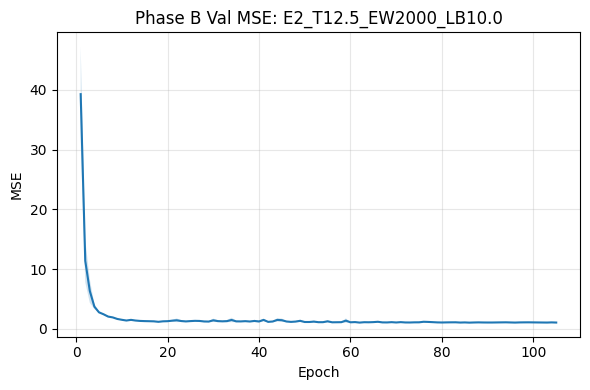

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\phase_b_val_mse_1.png


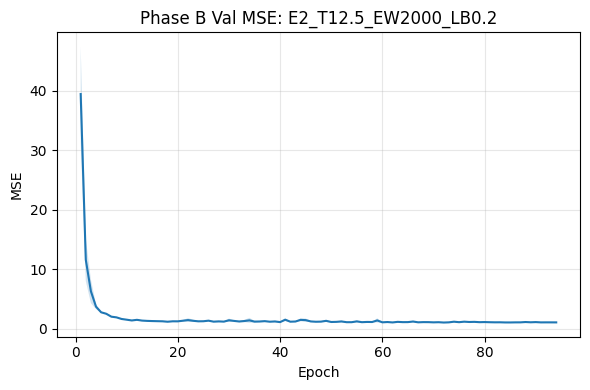

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\phase_b_val_mse_2.png


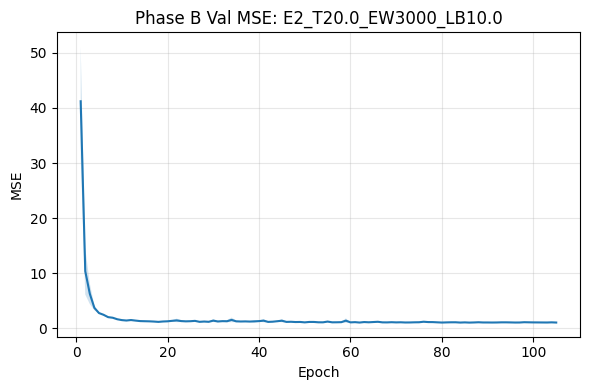

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\phase_b_val_mse_3.png


In [7]:
# =========================
# Phase B: Multi-seed confirmation on top Phase A configs
# =========================

PHASE_B_EPOCHS = BASELINE_CFG["epochs"]
PHASE_B_SEEDS = [0, 1, 2]

PHASE_B_EARLY_STOP = EarlyStopConfig(
    patience=BASELINE_CFG.get("early_stop", {}).get("patience", 25),
    min_delta=BASELINE_CFG.get("early_stop", {}).get("min_delta", 0.0),
    restore_best=True,
)

PHASE_B_SCHED = SchedConfig(**BASELINE_CFG.get("scheduler", {})) if BASELINE_CFG.get("scheduler") else SchedConfig()

BEST_CONFIG_PATH = RESULTS_DIR / "best_config.json"
PHASE_B_TOPK = 5  # how many Phase A configs to re-evaluate with multiple seeds


def _pick_best_from_phase_a_any():
    """Pick a single best config from whatever Phase A produced."""
    if "phase_a_topk" in globals() and phase_a_topk is not None and len(phase_a_topk) > 0:
        row = phase_a_topk.sort_values("best_val_mse").iloc[0]
    elif "phase_a_df" in globals() and phase_a_df is not None and len(phase_a_df) > 0:
        row = phase_a_df.sort_values("best_val_mse").iloc[0]
    else:
        return None

    return {
        "num_experts": int(row["num_experts"]),
        "tau": float(row["tau"]),
        "entropy_weight": float(row["entropy_weight"]),
        "lambda_balance": float(row["lambda_balance"]),
    }


def _phase_b_candidates():
    """
    Phase B candidates should come from Phase A.
    If phase_a_topk is empty (often due to collapse-filter), fall back to best K from phase_a_df.
    """
    if "phase_a_topk" in globals() and phase_a_topk is not None and len(phase_a_topk) > 0:
        return phase_a_topk.copy().reset_index(drop=True)

    if "phase_a_df" in globals() and phase_a_df is not None and len(phase_a_df) > 0:
        # Don't apply collapse filtering here; Phase B is exactly to re-check robustness.
        needed = ["num_experts", "tau", "entropy_weight", "lambda_balance", "best_val_mse"]
        missing = [c for c in needed if c not in phase_a_df.columns]
        if missing:
            raise RuntimeError(f"phase_a_df missing columns for Phase B: {missing}")

        return (
            phase_a_df.sort_values("best_val_mse")
            .head(PHASE_B_TOPK)
            .reset_index(drop=True)
        )

    # absolute fallback: single best config if available
    best = _pick_best_from_phase_a_any()
    if best is None:
        raise RuntimeError("Phase A produced no configs at all (phase_a_topk and phase_a_df empty).")
    return pd.DataFrame([best])


phase_b_candidates = _phase_b_candidates()

if "phase_a_topk" in globals() and (phase_a_topk is None or len(phase_a_topk) == 0):
    print("⚠️ Phase A topk is empty (likely due to collapse filter). Phase B will use best configs from phase_a_df instead.")
print(f"Phase B will evaluate {len(phase_b_candidates)} configs × {len(PHASE_B_SEEDS)} seeds = {len(phase_b_candidates)*len(PHASE_B_SEEDS)} runs.")

phase_b_rows = []
phase_b_histories = {}

for row in phase_b_candidates.to_dict(orient="records"):
    cfg_key = f"E{row['num_experts']}_T{row['tau']}_EW{row['entropy_weight']}_LB{row['lambda_balance']}"
    seed_histories = []
    seed_rows = []

    for seed in PHASE_B_SEEDS:
        model, history = train_moe(
            num_experts=int(row["num_experts"]),
            tau=float(row["tau"]),
            entropy_weight=float(row["entropy_weight"]),
            lambda_balance=float(row["lambda_balance"]),
            seed=int(seed),
            max_epochs=PHASE_B_EPOCHS,
            early_stop_cfg=PHASE_B_EARLY_STOP,
            sched_cfg=PHASE_B_SCHED,
        )

        # Defensive checks (so you get a clear error instead of silent failure)
        for k in ["val_mse", "val_mae", "val_entropy", "val_usage_soft_min", "val_usage_hard_min"]:
            if k not in history:
                raise KeyError(f"history missing key '{k}'. Available keys: {list(history.keys())}")

        best_idx = int(np.argmin(history["val_mse"]))
        seed_rows.append(
            {
                "seed": int(seed),
                "best_val_mse": float(history["val_mse"][best_idx]),
                "best_val_mae": float(history["val_mae"][best_idx]),
                "mean_val_entropy": float(np.mean(history["val_entropy"])),
                "min_usage_soft": float(np.min(history["val_usage_soft_min"])),
                "min_usage_hard": float(np.min(history["val_usage_hard_min"])),
            }
        )
        seed_histories.append(history)

    phase_b_histories[cfg_key] = seed_histories
    seed_df = pd.DataFrame(seed_rows)

    phase_b_rows.append(
        {
            "config": cfg_key,
            "num_experts": int(row["num_experts"]),
            "tau": float(row["tau"]),
            "entropy_weight": float(row["entropy_weight"]),
            "lambda_balance": float(row["lambda_balance"]),
            "val_mse_mean": float(seed_df["best_val_mse"].mean()),
            "val_mse_std": float(seed_df["best_val_mse"].std(ddof=0)),
            "val_mae_mean": float(seed_df["best_val_mae"].mean()),
            "val_mae_std": float(seed_df["best_val_mae"].std(ddof=0)),
            "entropy_mean": float(seed_df["mean_val_entropy"].mean()),
            "entropy_std": float(seed_df["mean_val_entropy"].std(ddof=0)),
            "min_usage_soft_mean": float(seed_df["min_usage_soft"].mean()),
            "min_usage_soft_std": float(seed_df["min_usage_soft"].std(ddof=0)),
            "min_usage_hard_mean": float(seed_df["min_usage_hard"].mean()),
            "min_usage_hard_std": float(seed_df["min_usage_hard"].std(ddof=0)),
        }
    )

# Build results DF
if len(phase_b_rows) == 0:
    print("⚠️ Phase B produced no rows. Saving BEST_CONFIG from Phase A best (single pick).")
    BEST_CONFIG = _pick_best_from_phase_a_any()
    if BEST_CONFIG is None:
        raise RuntimeError("Cannot pick BEST_CONFIG: no Phase A results found.")
    BEST_CONFIG_PATH.write_text(json.dumps(BEST_CONFIG, indent=2))
    print(f"Saved BEST_CONFIG to: {BEST_CONFIG_PATH}")
    phase_b_df = pd.DataFrame()
else:
    phase_b_df = (
        pd.DataFrame(phase_b_rows)
        .sort_values(["val_mse_mean", "val_mse_std", "val_mae_mean"])
        .reset_index(drop=True)
    )

    phase_b_path = RESULTS_DIR / "phase_b_results.csv"
    phase_b_df.to_csv(phase_b_path, index=False)
    print(f"Phase B results saved to: {phase_b_path}")

    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(phase_b_df)

    # Pick robust best config
    best_row = phase_b_df.iloc[0]
    BEST_CONFIG = {
        "num_experts": int(best_row["num_experts"]),
        "tau": float(best_row["tau"]),
        "entropy_weight": float(best_row["entropy_weight"]),
        "lambda_balance": float(best_row["lambda_balance"]),
    }
    BEST_CONFIG_PATH.write_text(json.dumps(BEST_CONFIG, indent=2))
    print("BEST_CONFIG:")
    print(BEST_CONFIG)
    print(f"Saved BEST_CONFIG to: {BEST_CONFIG_PATH}")

    # Plot validation MSE curves for the top few configs
    TOP_PLOT = min(3, len(phase_b_df))
    for idx in range(TOP_PLOT):
        row = phase_b_df.iloc[idx]
        cfg_key = row["config"]
        histories = phase_b_histories[cfg_key]

        min_len = min(len(h["val_mse"]) for h in histories)
        val_mse_stack = np.stack([np.array(h["val_mse"][:min_len]) for h in histories], axis=0)
        mean_curve = val_mse_stack.mean(axis=0)
        std_curve = val_mse_stack.std(axis=0)

        epochs = np.arange(1, min_len + 1)
        plt.figure(figsize=(6, 4))
        plt.plot(epochs, mean_curve, label="val MSE")
        plt.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)
        plt.title(f"Phase B Val MSE: {cfg_key}")
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.grid(True, alpha=0.3)
        plot_path = PLOTS_DIR / f"phase_b_val_mse_{idx+1}.png"
        plt.tight_layout()
        plt.savefig(plot_path, dpi=150)
        plt.show()
        print(f"Saved: {plot_path}")


## Final training + baseline comparison


=== BEST_CONFIG (Hard MoE) ===
{
  "num_experts": 2,
  "tau": 12.5,
  "entropy_weight": 2000.0,
  "lambda_balance": 10.0
}
Loaded MoE checkpoint: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\checkpoints\hard_moe_seed0.pt
Loaded MoE checkpoint: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\checkpoints\hard_moe_seed1.pt
Loaded MoE checkpoint: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\checkpoints\hard_moe_seed2.pt
Loaded baseline checkpoint: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\checkpoints\baseline_seed0.pt
Loaded baseline checkpoint: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\checkpoints\baseline_seed1.pt
Loaded baseline checkpoint: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\checkpoints\baseline_seed2.pt
Skipping val-curve plots (trainin

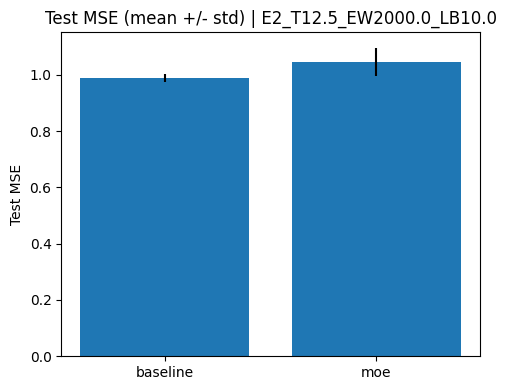

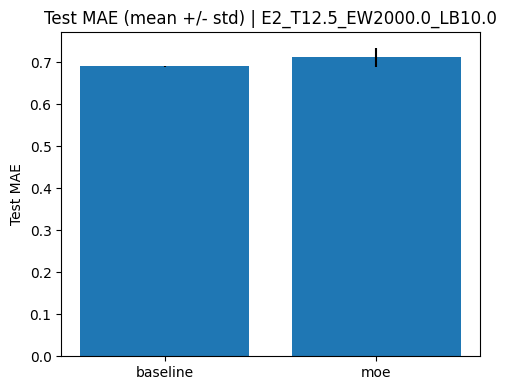

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\final_test_mse_bar.png
Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\final_test_mae_bar.png


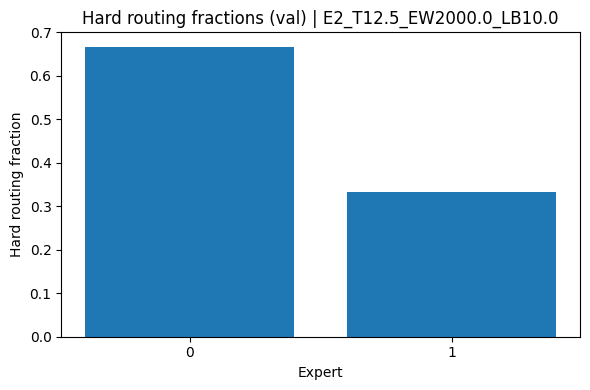

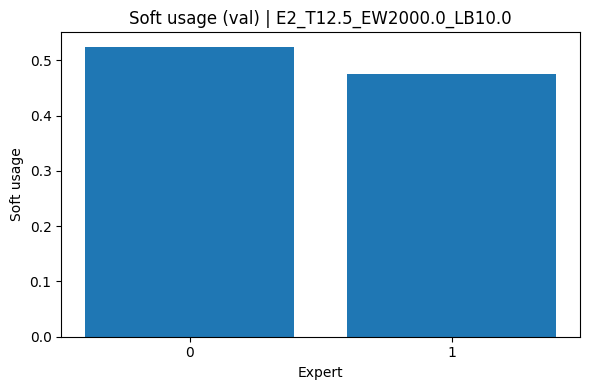

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\moe_usage_hard.png
Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\moe_usage_soft.png
Skipping gate-entropy plot (training histories not found).


,model,config,val_mse,val_mae,test_mse,test_mae,mean_entropy,min_usage_soft,min_usage_hard
0,baseline,"{""encoder_hidden"": [512, 256, 128, 64], ""head_...",1.0267 +/- 0.0091,0.7290 +/- 0.0066,0.9887 +/- 0.0157,0.6906 +/- 0.0006,-,-,-
1,hard_moe,"{""num_experts"": 2, ""tau"": 12.5, ""entropy_weigh...",1.0309 +/- 0.0159,0.7322 +/- 0.0108,1.0464 +/- 0.0499,0.7119 +/- 0.0230,0.6888 +/- 0.0061,0.4719 +/- 0.0335,0.0000 +/- 0.0000


Saved summary to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\results\final_summary.csv
BEST_CONFIG tag: E2_T12.5_EW2000.0_LB10.0


In [14]:
from pathlib import Path

# ----------------------------
# Load BEST_CONFIG
# ----------------------------
FINAL_SEEDS = PHASE_B_SEEDS
FINAL_EPOCHS = BASELINE_CFG["epochs"]
FINAL_EARLY_STOP = EarlyStopConfig(
    patience=BASELINE_CFG.get("early_stop", {}).get("patience", 25),
    min_delta=BASELINE_CFG.get("early_stop", {}).get("min_delta", 0.0),
    restore_best=True,
 )
FINAL_SCHED = PHASE_B_SCHED

BEST_CONFIG_PATH = RESULTS_DIR / "best_config.json"
if "BEST_CONFIG" not in globals():
    if BEST_CONFIG_PATH.exists():
        BEST_CONFIG = json.loads(BEST_CONFIG_PATH.read_text())
        print(f"Loaded BEST_CONFIG from: {BEST_CONFIG_PATH}")
    else:
        raise RuntimeError("BEST_CONFIG is not available. Run Phase B first.")

# Pretty print
print("\n=== BEST_CONFIG (Hard MoE) ===")
print(json.dumps(BEST_CONFIG, indent=2))

# Save a snapshot next to plots for traceability
(PLOTS_DIR / "final_best_config_snapshot.json").write_text(json.dumps(BEST_CONFIG, indent=2))

best_tag = (
    f"E{BEST_CONFIG['num_experts']}"
    f"_T{BEST_CONFIG['tau']}"
    f"_EW{BEST_CONFIG['entropy_weight']}"
    f"_LB{BEST_CONFIG['lambda_balance']}"
 )

# Safe tau for evaluation
FINAL_TAU = float(BEST_CONFIG.get("tau", 1.0))

# ----------------------------
# Checkpoint-driven mode
# ----------------------------
USE_CHECKPOINTS = True
RUN_IF_MISSING = False  # set True to retrain if a checkpoint is missing
LOAD_HISTORIES = True

# Ensure required dirs are defined (in case this cell is run standalone)
if any(k not in globals() for k in ["CHECKPOINTS_DIR", "RESULTS_DIR", "PLOTS_DIR", "HISTORIES_DIR"]):
    try:
        NOTEBOOK_DIR = Path(__file__).resolve().parent
    except NameError:
        NOTEBOOK_DIR = Path.cwd()
    ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "hard_moe"
    CHECKPOINTS_DIR = ARTIFACT_ROOT / "checkpoints"
    RESULTS_DIR = ARTIFACT_ROOT / "results"
    PLOTS_DIR = ARTIFACT_ROOT / "plots"
    HISTORIES_DIR = ARTIFACT_ROOT / "training_histories"
    for _p in (CHECKPOINTS_DIR, RESULTS_DIR, PLOTS_DIR, HISTORIES_DIR):
        _p.mkdir(parents=True, exist_ok=True)

def _load_history(path: Path):
    if path.exists():
        with path.open("r") as f:
            return json.load(f)
    return None

def _save_history(path: Path, history: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w") as f:
        json.dump(history, f)

def _eval_moe_safe(model: nn.Module, loader, tau: float):
    model.eval()
    loss_fn = nn.MSELoss(reduction="sum")
    total_mse = 0.0
    total_mae = 0.0
    total_entropy = 0.0
    usage_soft_sum = None
    usage_hard_sum = None
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            try:
                out = model(xb, tau=tau, use_gumbel=False)
            except TypeError:
                out = model(xb, tau=tau)
            y_hat = out["y_hat"]
            p = out["p"]
            g_hard = out["g_hard"]
            total_mse += loss_fn(y_hat, yb).item()
            total_mae += torch.sum(torch.abs(y_hat - yb)).item()
            entropy = -(p * torch.log(p + 1e-9)).sum(dim=1).mean()
            total_entropy += entropy.item() * yb.shape[0]
            usage_soft = p.sum(dim=0)
            usage_hard = g_hard.sum(dim=0)
            if usage_soft_sum is None:
                usage_soft_sum = usage_soft.detach().clone()
                usage_hard_sum = usage_hard.detach().clone()
            else:
                usage_soft_sum += usage_soft.detach()
                usage_hard_sum += usage_hard.detach()
            n += yb.shape[0]
    usage_soft_mean = (usage_soft_sum / max(n, 1)).cpu().numpy()
    usage_hard_mean = (usage_hard_sum / max(n, 1)).cpu().numpy()
    return {
        "mse": total_mse / max(n, 1),
        "mae": total_mae / max(n, 1),
        "entropy": total_entropy / max(n, 1),
        "usage_soft": usage_soft_mean,
        "usage_hard": usage_hard_mean,
        "usage_soft_min": float(np.min(usage_soft_mean)),
        "usage_hard_min": float(np.min(usage_hard_mean)),
    }

# ----------------------------
# Run FINAL MoE over seeds (or load checkpoints)
# ----------------------------
moe_histories = []
moe_val_metrics = []
moe_test_metrics = []
moe_usage_soft = []
moe_usage_hard = []

for seed in FINAL_SEEDS:
    ckpt_path = CHECKPOINTS_DIR / f"hard_moe_seed{seed}.pt"
    hist_path = HISTORIES_DIR / f"hard_moe_seed{seed}.json"

    if USE_CHECKPOINTS and ckpt_path.exists():
        model = HardMoERegressor(
            input_dim=INPUT_DIM,
            num_experts=BEST_CONFIG["num_experts"],
            expert_hidden=BASELINE_CFG["encoder_hidden"],
            dropout=BASELINE_CFG["dropout"],
            gate_hidden=(128, 64),
        ).to(DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        print(f"Loaded MoE checkpoint: {ckpt_path}")

        if LOAD_HISTORIES:
            hist = _load_history(hist_path)
            if hist is not None:
                moe_histories.append(hist)

        val_metrics = _eval_moe_safe(model, val_loader, tau=FINAL_TAU)
        moe_val_metrics.append(
            {
                "seed": int(seed),
                "val_mse": float(val_metrics["mse"]),
                "val_mae": float(val_metrics["mae"]),
                "entropy": float(val_metrics["entropy"]),
                "min_usage_soft": float(val_metrics["usage_soft_min"]),
                "min_usage_hard": float(val_metrics["usage_hard_min"]),
            }
        )
        test_metrics = _eval_moe_safe(model, test_loader, tau=FINAL_TAU)
        moe_test_metrics.append({"seed": int(seed), "test_mse": float(test_metrics["mse"]), "test_mae": float(test_metrics["mae"])})

        moe_usage_soft.append(np.array(val_metrics["usage_soft"], dtype=np.float64))
        moe_usage_hard.append(np.array(val_metrics["usage_hard"], dtype=np.float64))
        continue

    if not RUN_IF_MISSING:
        print(f"Missing MoE checkpoint for seed {seed}. Skipping (RUN_IF_MISSING=False).")
        continue

    model, history = train_moe(
        num_experts=BEST_CONFIG["num_experts"],
        tau=FINAL_TAU,
        entropy_weight=BEST_CONFIG["entropy_weight"],
        lambda_balance=BEST_CONFIG["lambda_balance"],
        seed=seed,
        max_epochs=FINAL_EPOCHS,
        early_stop_cfg=FINAL_EARLY_STOP,
        sched_cfg=FINAL_SCHED,
    )
    moe_histories.append(history)
    _save_history(hist_path, history)

    best_idx = int(np.argmin(history["val_mse"]))
    moe_val_metrics.append(
        {
            "seed": int(seed),
            "val_mse": float(history["val_mse"][best_idx]),
            "val_mae": float(history["val_mae"][best_idx]),
            "entropy": float(history["val_entropy"][best_idx]),
            "min_usage_soft": float(history["val_usage_soft_min"][best_idx]),
            "min_usage_hard": float(history["val_usage_hard_min"][best_idx]),
        }
    )

    test_metrics = _eval_moe_safe(model, test_loader, tau=FINAL_TAU)
    moe_test_metrics.append({"seed": int(seed), "test_mse": float(test_metrics["mse"]), "test_mae": float(test_metrics["mae"])})

    usage_soft, usage_hard = collect_moe_usage(model, val_loader, tau=FINAL_TAU)
    moe_usage_soft.append(np.array(usage_soft, dtype=np.float64))
    moe_usage_hard.append(np.array(usage_hard, dtype=np.float64))

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": {**BEST_CONFIG, "epochs": FINAL_EPOCHS},
            "seed": seed,
            "input_dim": INPUT_DIM,
        },
        ckpt_path,
    )

# ----------------------------
# Run FINAL Baseline over seeds (or load checkpoints)
# ----------------------------
baseline_histories = []
baseline_val_metrics = []
baseline_test_metrics = []

for seed in FINAL_SEEDS:
    ckpt_path = CHECKPOINTS_DIR / f"baseline_seed{seed}.pt"
    hist_path = HISTORIES_DIR / f"baseline_seed{seed}.json"

    if USE_CHECKPOINTS and ckpt_path.exists():
        model = TabularRegressor(
            mode="shared",
            input_dim=INPUT_DIM,
            encoder_hidden=BASELINE_CFG["encoder_hidden"],
            head_hidden=BASELINE_CFG["head_hidden"],
            dropout=BASELINE_CFG["dropout"],
            output_dim=1,
        ).to(DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        print(f"Loaded baseline checkpoint: {ckpt_path}")

        if LOAD_HISTORIES:
            hist = _load_history(hist_path)
            if hist is not None:
                baseline_histories.append(hist)

        val_metrics = evaluate_baseline(model, val_loader)
        baseline_val_metrics.append(
            {
                "seed": int(seed),
                "val_mse": float(val_metrics["mse"]),
                "val_mae": float(val_metrics["mae"]),
            }
        )
        test_metrics = evaluate_baseline(model, test_loader)
        baseline_test_metrics.append({"seed": int(seed), "test_mse": float(test_metrics["mse"]), "test_mae": float(test_metrics["mae"])})
        continue

    if not RUN_IF_MISSING:
        print(f"Missing baseline checkpoint for seed {seed}. Skipping (RUN_IF_MISSING=False).")
        continue

    model, history = train_baseline(
        seed=seed,
        max_epochs=FINAL_EPOCHS,
        early_stop_cfg=FINAL_EARLY_STOP,
        sched_cfg=FINAL_SCHED,
    )
    baseline_histories.append(history)
    _save_history(hist_path, history)

    best_idx = int(np.argmin(history["val_mse"]))
    baseline_val_metrics.append(
        {
            "seed": int(seed),
            "val_mse": float(history["val_mse"][best_idx]),
            "val_mae": float(history["val_mae"][best_idx]),
        }
    )

    test_metrics = evaluate_baseline(model, test_loader)
    baseline_test_metrics.append({"seed": int(seed), "test_mse": float(test_metrics["mse"]), "test_mae": float(test_metrics["mae"])})

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": BASELINE_CFG,
            "seed": seed,
            "input_dim": INPUT_DIM,
        },
        ckpt_path,
    )

# ----------------------------
# Helpers
# ----------------------------
def _mean_std(series: List[float]):
    arr = np.array(series, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))

def _fmt(mean: float, std: float):
    return f"{mean:.4f} +/- {std:.4f}"

def _mean_std_curve(histories, key: str, max_len: int):
    stack = np.stack([np.array(h[key][:max_len], dtype=np.float64) for h in histories], axis=0)
    return stack.mean(axis=0), stack.std(axis=0)

def _plot_compare(histories_a, histories_b, key: str, label_a: str, label_b: str, ylabel: str, title: str, out_path: Path):
    min_len = min(min(len(h[key]) for h in histories_a), min(len(h[key]) for h in histories_b))
    mean_a, std_a = _mean_std_curve(histories_a, key, min_len)
    mean_b, std_b = _mean_std_curve(histories_b, key, min_len)
    epochs = np.arange(1, min_len + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, mean_a, label=label_a)
    plt.fill_between(epochs, mean_a - std_a, mean_a + std_a, alpha=0.2)
    plt.plot(epochs, mean_b, label=label_b)
    plt.fill_between(epochs, mean_b - std_b, mean_b + std_b, alpha=0.2)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()

# ----------------------------
# Validation curves: MSE and MAE (only if histories are available)
# ----------------------------
val_mse_plot = PLOTS_DIR / "final_val_mse_baseline_vs_moe.png"
val_mae_plot = PLOTS_DIR / "final_val_mae_baseline_vs_moe.png"

if len(baseline_histories) > 0 and len(moe_histories) > 0:
    _plot_compare(
        baseline_histories, moe_histories,
        "val_mse", "baseline", "hard_moe", "Val MSE",
        title=f"Val MSE vs Epoch (baseline vs hard_moe) | {best_tag}",
        out_path=val_mse_plot
    )

    _plot_compare(
        baseline_histories, moe_histories,
        "val_mae", "baseline", "hard_moe", "Val MAE",
        title=f"Val MAE vs Epoch (baseline vs hard_moe) | {best_tag}",
        out_path=val_mae_plot
    )

    print(f"Saved: {val_mse_plot}")
    print(f"Saved: {val_mae_plot}")
else:
    print("Skipping val-curve plots (training histories not found).")

# ----------------------------
# Test performance comparison (mean +/- std over seeds)
# ----------------------------
baseline_test_df = pd.DataFrame(baseline_test_metrics)
moe_test_df = pd.DataFrame(moe_test_metrics)

if len(baseline_test_df) > 0 and len(moe_test_df) > 0:
    baseline_test_mean, baseline_test_std = _mean_std(baseline_test_df["test_mse"].tolist())
    moe_test_mean, moe_test_std = _mean_std(moe_test_df["test_mse"].tolist())

    plt.figure(figsize=(5, 4))
    plt.bar(["baseline", "moe"], [baseline_test_mean, moe_test_mean], yerr=[baseline_test_std, moe_test_std])
    plt.ylabel("Test MSE")
    plt.title(f"Test MSE (mean +/- std) | {best_tag}")
    plt.tight_layout()
    bar_path = PLOTS_DIR / "final_test_mse_bar.png"
    plt.savefig(bar_path, dpi=150)
    plt.show()

    baseline_test_mean, baseline_test_std = _mean_std(baseline_test_df["test_mae"].tolist())
    moe_test_mean, moe_test_std = _mean_std(moe_test_df["test_mae"].tolist())

    plt.figure(figsize=(5, 4))
    plt.bar(["baseline", "moe"], [baseline_test_mean, moe_test_mean], yerr=[baseline_test_std, moe_test_std])
    plt.ylabel("Test MAE")
    plt.title(f"Test MAE (mean +/- std) | {best_tag}")
    plt.tight_layout()
    bar_path_mae = PLOTS_DIR / "final_test_mae_bar.png"
    plt.savefig(bar_path_mae, dpi=150)
    plt.show()

    print(f"Saved: {bar_path}")
    print(f"Saved: {bar_path_mae}")
else:
    print("Skipping test bars (missing test metrics).")

# ----------------------------
# Expert usage bars (mean across seeds)
# ----------------------------
if len(moe_usage_soft) > 0 and len(moe_usage_hard) > 0:
    moe_usage_soft_mean = np.mean(np.stack(moe_usage_soft, axis=0), axis=0)
    moe_usage_hard_mean = np.mean(np.stack(moe_usage_hard, axis=0), axis=0)

    K = len(moe_usage_hard_mean)
    xs = np.arange(K)

    plt.figure(figsize=(6, 4))
    plt.bar(xs, moe_usage_hard_mean)
    plt.xticks(xs, [str(i) for i in xs])
    plt.xlabel("Expert")
    plt.ylabel("Hard routing fraction")
    plt.title(f"Hard routing fractions (val) | {best_tag}")
    plt.tight_layout()
    usage_hard_path = PLOTS_DIR / "moe_usage_hard.png"
    plt.savefig(usage_hard_path, dpi=150)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.bar(xs, moe_usage_soft_mean)
    plt.xticks(xs, [str(i) for i in xs])
    plt.xlabel("Expert")
    plt.ylabel("Soft usage")
    plt.title(f"Soft usage (val) | {best_tag}")
    plt.tight_layout()
    usage_soft_path = PLOTS_DIR / "moe_usage_soft.png"
    plt.savefig(usage_soft_path, dpi=150)
    plt.show()

    print(f"Saved: {usage_hard_path}")
    print(f"Saved: {usage_soft_path}")
else:
    print("Skipping usage plots (missing MoE usage stats).")

# ----------------------------
# Gate entropy vs epochs (MoE)
# ----------------------------
if len(moe_histories) > 0:
    min_len = min(len(h["val_entropy"]) for h in moe_histories)
    entropy_stack = np.stack([np.array(h["val_entropy"][:min_len], dtype=np.float64) for h in moe_histories], axis=0)
    entropy_mean = entropy_stack.mean(axis=0)
    entropy_std = entropy_stack.std(axis=0)

    epochs = np.arange(1, min_len + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, entropy_mean)
    plt.fill_between(epochs, entropy_mean - entropy_std, entropy_mean + entropy_std, alpha=0.2)
    plt.xlabel("Epoch")
    plt.ylabel("Gate entropy")
    plt.title(f"MoE gate entropy vs epoch | {best_tag}")
    plt.tight_layout()
    entropy_path = PLOTS_DIR / "moe_gate_entropy.png"
    plt.savefig(entropy_path, dpi=150)
    plt.show()

    print(f"Saved: {entropy_path}")
else:
    print("Skipping gate-entropy plot (training histories not found).")

# ----------------------------
# Summary table (mean +/- std)
# ----------------------------
baseline_val_df = pd.DataFrame(baseline_val_metrics)
moe_val_df = pd.DataFrame(moe_val_metrics)

if len(baseline_val_df) > 0 and len(moe_val_df) > 0:
    summary_rows = []

    baseline_val_mse_mean, baseline_val_mse_std = _mean_std(baseline_val_df["val_mse"].tolist())
    baseline_val_mae_mean, baseline_val_mae_std = _mean_std(baseline_val_df["val_mae"].tolist())
    baseline_test_mse_mean, baseline_test_mse_std = _mean_std(baseline_test_df["test_mse"].tolist())
    baseline_test_mae_mean, baseline_test_mae_std = _mean_std(baseline_test_df["test_mae"].tolist())

    summary_rows.append(
        {
            "model": "baseline",
            "config": json.dumps(BASELINE_CFG),
            "val_mse": _fmt(baseline_val_mse_mean, baseline_val_mse_std),
            "val_mae": _fmt(baseline_val_mae_mean, baseline_val_mae_std),
            "test_mse": _fmt(baseline_test_mse_mean, baseline_test_mse_std),
            "test_mae": _fmt(baseline_test_mae_mean, baseline_test_mae_std),
            "mean_entropy": "-",
            "min_usage_soft": "-",
            "min_usage_hard": "-",
        }
    )

    moe_val_mse_mean, moe_val_mse_std = _mean_std(moe_val_df["val_mse"].tolist())
    moe_val_mae_mean, moe_val_mae_std = _mean_std(moe_val_df["val_mae"].tolist())
    moe_test_mse_mean, moe_test_mse_std = _mean_std(moe_test_df["test_mse"].tolist())
    moe_test_mae_mean, moe_test_mae_std = _mean_std(moe_test_df["test_mae"].tolist())
    moe_entropy_mean, moe_entropy_std = _mean_std(moe_val_df["entropy"].tolist())
    moe_min_usage_soft_mean, moe_min_usage_soft_std = _mean_std(moe_val_df["min_usage_soft"].tolist())
    moe_min_usage_hard_mean, moe_min_usage_hard_std = _mean_std(moe_val_df["min_usage_hard"].tolist())

    summary_rows.append(
        {
            "model": "hard_moe",
            "config": json.dumps(BEST_CONFIG),
            "val_mse": _fmt(moe_val_mse_mean, moe_val_mse_std),
            "val_mae": _fmt(moe_val_mae_mean, moe_val_mae_std),
            "test_mse": _fmt(moe_test_mse_mean, moe_test_mse_std),
            "test_mae": _fmt(moe_test_mae_mean, moe_test_mae_std),
            "mean_entropy": _fmt(moe_entropy_mean, moe_entropy_std),
            "min_usage_soft": _fmt(moe_min_usage_soft_mean, moe_min_usage_soft_std),
            "min_usage_hard": _fmt(moe_min_usage_hard_mean, moe_min_usage_hard_std),
        }
    )

    summary_df = pd.DataFrame(summary_rows)
    summary_path = RESULTS_DIR / "final_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    with pd.option_context("display.max_columns", None):
        display(summary_df)
    print(f"Saved summary to: {summary_path}")
    print(f"BEST_CONFIG tag: {best_tag}")
else:
    print("Skipping summary table (missing val metrics).")

## Plots + summary tables

Using FINAL_SEEDS=[0, 1, 2]


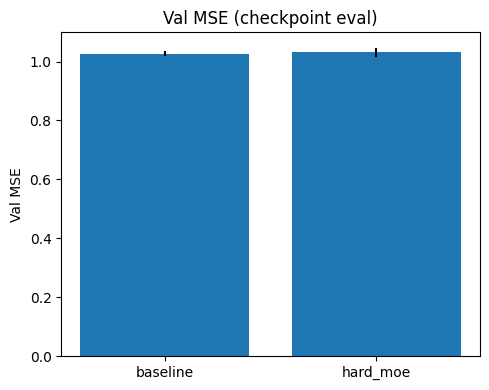

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\final_val_mse_bar.png
Δ Val MSE (hard_moe - baseline): 0.004166 (+0.41%)


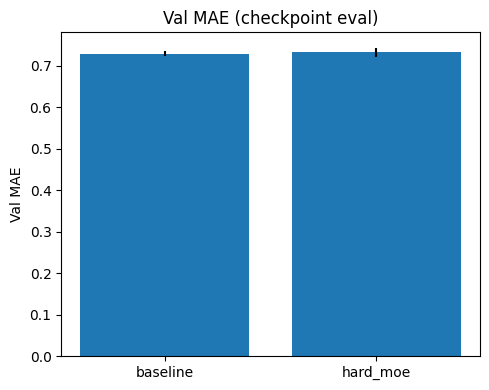

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\final_val_mae_bar.png
Δ Val MAE (hard_moe - baseline): 0.003127 (+0.43%)


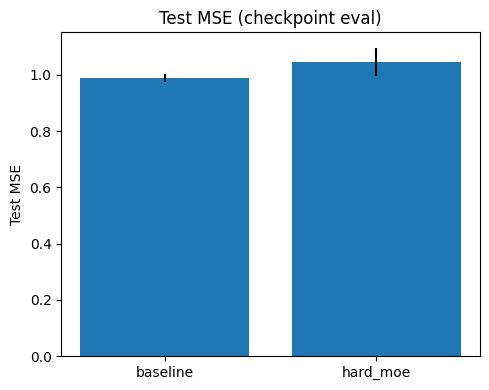

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\final_test_mse_bar.png
Δ Test MSE (hard_moe - baseline): 0.057762 (+5.84%)


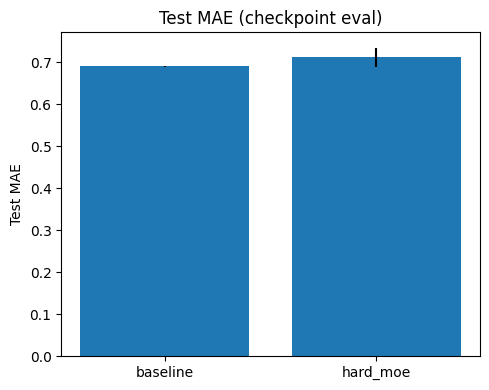

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\final_test_mae_bar.png
Δ Test MAE (hard_moe - baseline): 0.021308 (+3.09%)


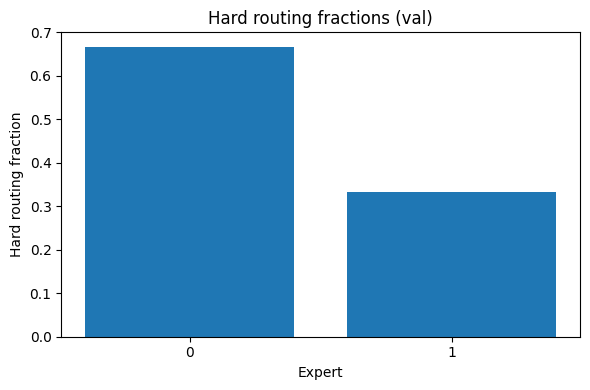

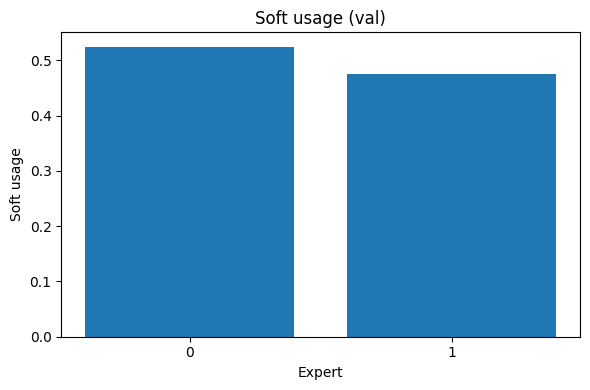

Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\moe_usage_hard.png
Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\plots\moe_usage_soft.png


,model,config,val_mse,val_mae,test_mse,test_mae,mean_entropy,min_usage_soft,min_usage_hard
0,baseline,"{""encoder_hidden"": [512, 256, 128, 64], ""head_...",1.0267 +/- 0.0091,0.7290 +/- 0.0066,0.9887 +/- 0.0157,0.6906 +/- 0.0006,-,-,-
1,hard_moe,"{""num_experts"": 2, ""tau"": 12.5, ""entropy_weigh...",1.0309 +/- 0.0159,0.7322 +/- 0.0108,1.0464 +/- 0.0499,0.7119 +/- 0.0230,0.6888 +/- 0.0061,0.4719 +/- 0.0335,0.0000 +/- 0.0000


Saved summary to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\results\final_summary.csv


,split,metric,baseline_mean,baseline_std,moe_mean,moe_std,delta_abs,delta_pct
0,val,MSE,1.026731,0.009101,1.030897,0.015896,0.004166,0.405778
1,val,MAE,0.729035,0.006569,0.732162,0.010800,0.003127,0.428906
2,test,MSE,0.988655,0.015684,1.046417,0.049928,0.057762,5.842506
3,test,MAE,0.690559,0.000629,0.711867,0.022995,0.021308,3.085646


Saved delta table to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hard_moe\results\final_delta_vs_baseline.csv
No history files found for best-epoch summary.

Interpretation:
- Negative deltas mean hard_moe is better (lower error) than baseline.
- Positive deltas mean hard_moe is worse.
- Compare val vs test to see if improvements generalize.
- Best-epoch stats show how quickly each model reached its best validation MSE.


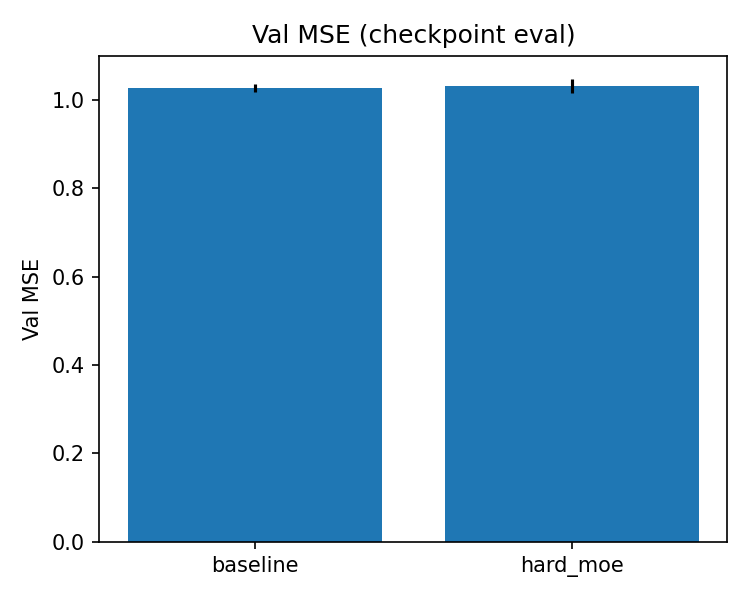

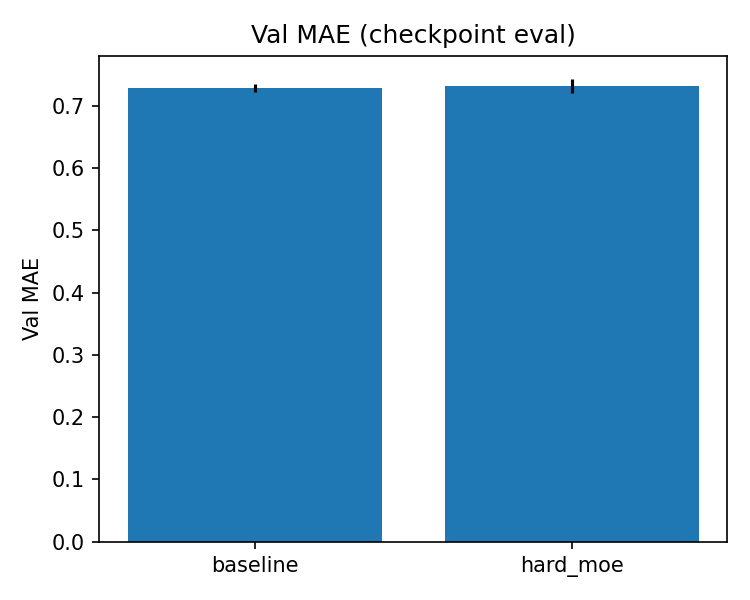

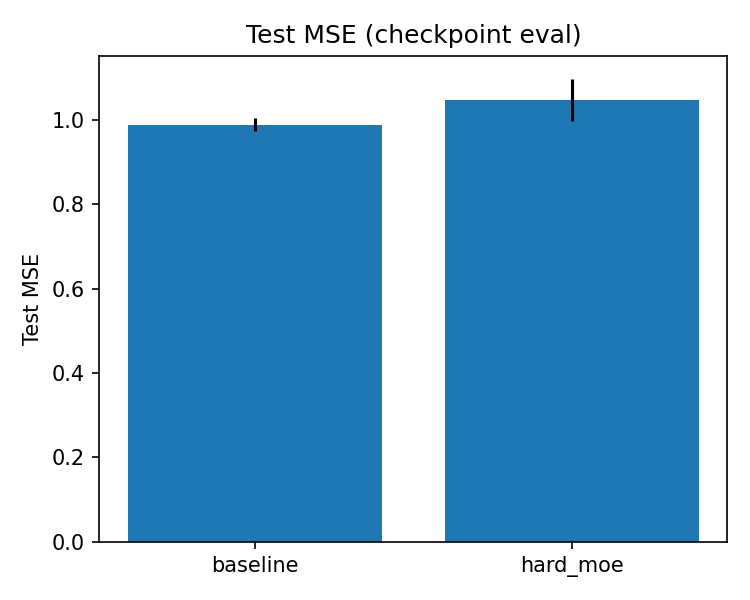

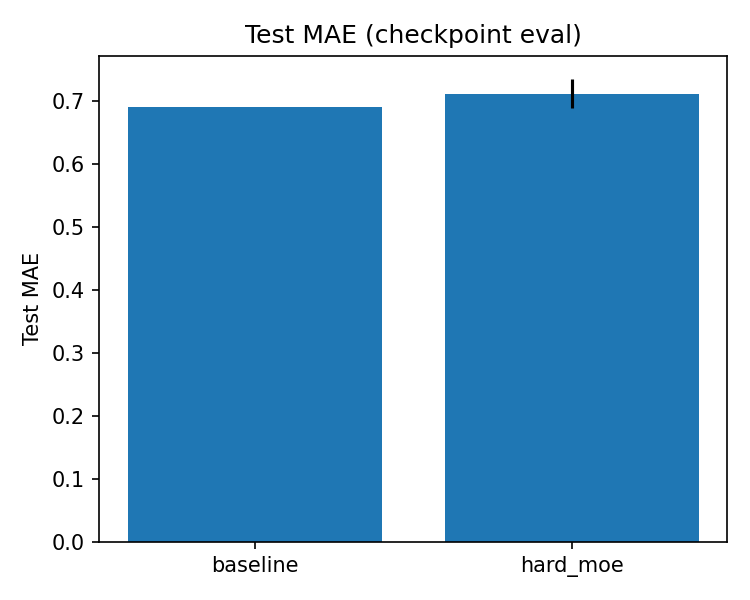

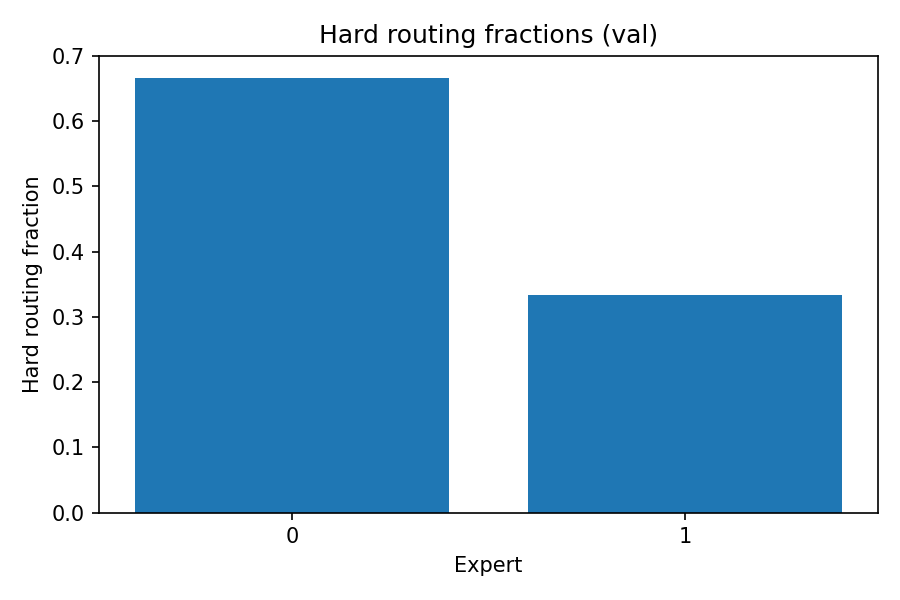

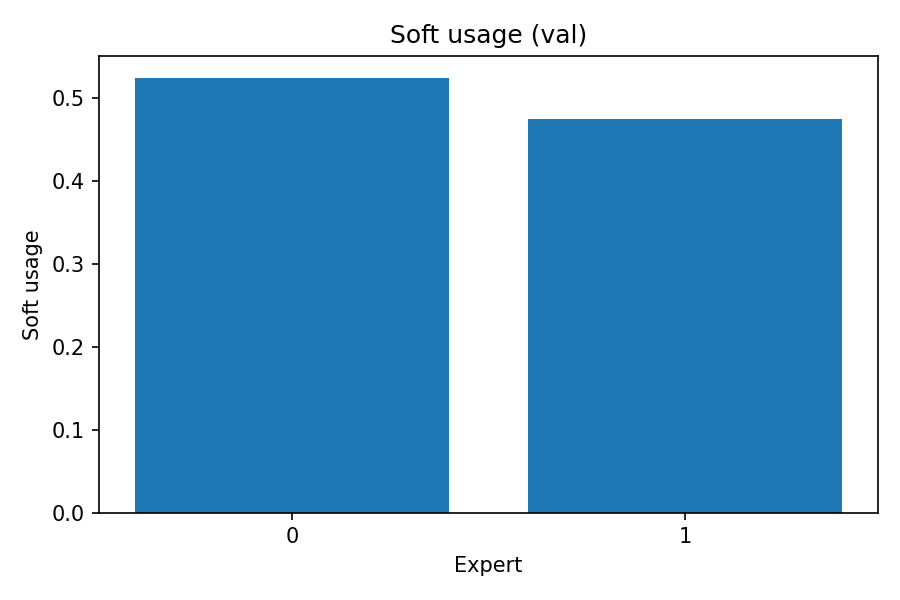

In [15]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple
import json
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ----------------------------
# Paths + config (standalone)
# ----------------------------
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "hard_moe"
CHECKPOINTS_DIR = ARTIFACT_ROOT / "checkpoints"
RESULTS_DIR = ARTIFACT_ROOT / "results"
PLOTS_DIR = ARTIFACT_ROOT / "plots"
HISTORIES_DIR = ARTIFACT_ROOT / "training_histories"
for _p in (CHECKPOINTS_DIR, RESULTS_DIR, PLOTS_DIR, HISTORIES_DIR):
    _p.mkdir(parents=True, exist_ok=True)

BASELINE_CONFIG_PATH = NOTEBOOK_DIR / "artifacts" / "baseline" / "results" / "config.json"
DEFAULT_BASELINE = {
    "encoder_hidden": (512, 256, 128, 64),
    "head_hidden": (),
    "dropout": 0.1,
    "lr": 3e-3,
    "weight_decay": 1e-4,
    "epochs": 200,
    "batch_size": 256,
    "seed": 0,
    "early_stop": {"patience": 25, "min_delta": 0.0, "restore_best": True},
    "scheduler": {"enabled": True, "mode": "min", "factor": 0.5, "patience": 8, "min_lr": 1e-6, "threshold": 1e-4},
}
BASELINE_CFG = DEFAULT_BASELINE.copy()
if BASELINE_CONFIG_PATH.exists():
    BASELINE_CFG.update(json.loads(BASELINE_CONFIG_PATH.read_text()))

def _to_tuple(x):
    return tuple(x) if isinstance(x, list) else x

BASELINE_CFG["encoder_hidden"] = _to_tuple(BASELINE_CFG.get("encoder_hidden", DEFAULT_BASELINE["encoder_hidden"]))
BASELINE_CFG["head_hidden"] = _to_tuple(BASELINE_CFG.get("head_hidden", DEFAULT_BASELINE["head_hidden"]))
BASELINE_CFG["dropout"] = float(BASELINE_CFG.get("dropout", DEFAULT_BASELINE["dropout"]))
BASELINE_CFG["batch_size"] = int(BASELINE_CFG.get("batch_size", DEFAULT_BASELINE["batch_size"]))

BEST_CONFIG_PATH = RESULTS_DIR / "best_config.json"
if not BEST_CONFIG_PATH.exists():
    raise RuntimeError("Missing best_config.json. Run Phase B at least once.")
BEST_CONFIG = json.loads(BEST_CONFIG_PATH.read_text())

# ----------------------------
# Data + loaders (standalone)
# ----------------------------
from torch.utils.data import DataLoader, TensorDataset
import data.encode_features as enc

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "all_features"
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

(
    X_train_np,
    X_val_np,
    X_test_np,
    y_train_np,
    y_val_np,
    y_test_np,
    _feature_artifacts,
 ) = enc.prepare_features(train_df, val_df, test_df)

INPUT_DIM = X_train_np.shape[1]
BATCH_SIZE = int(BASELINE_CFG["batch_size"])
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(y_train_np)),
    batch_size=BATCH_SIZE,
    shuffle=True,
 )
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val_np), torch.from_numpy(y_val_np)),
    batch_size=BATCH_SIZE,
    shuffle=False,
 )
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_np), torch.from_numpy(y_test_np)),
    batch_size=BATCH_SIZE,
    shuffle=False,
 )

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Models (minimal, for inference)
# ----------------------------
from models.model import TabularRegressor

class GateNet(nn.Module):
    def __init__(self, input_dim: int, num_experts: int, hidden_dims: Tuple[int, ...] = (128, 64), dropout: float = 0.1):
        super().__init__()
        layers = []
        dims = [input_dim, *hidden_dims]
        if hidden_dims:
            for d_in, d_out in zip(dims[:-1], dims[1:]):
                layers.append(nn.Linear(d_in, d_out))
                layers.append(nn.ReLU())
                if dropout and dropout > 0:
                    layers.append(nn.Dropout(dropout))
            layers.append(nn.Linear(dims[-1], num_experts))
        else:
            layers.append(nn.Linear(input_dim, num_experts))
        self.net = nn.Sequential(*layers)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class HardMoERegressor(nn.Module):
    def __init__(self, input_dim: int, num_experts: int, expert_hidden: Tuple[int, ...], dropout: float, gate_hidden: Tuple[int, ...] = (128, 64)):
        super().__init__()
        self.num_experts = num_experts
        self.gate = GateNet(input_dim, num_experts, hidden_dims=gate_hidden, dropout=dropout)
        self.experts = nn.ModuleList(
            [
                TabularRegressor(
                    mode="shared",
                    input_dim=input_dim,
                    encoder_hidden=expert_hidden,
                    head_hidden=(),
                    dropout=dropout,
                    output_dim=1,
                )
                for _ in range(num_experts)
            ]
        )
    def forward(self, x: torch.Tensor, tau: float = 1.0):
        logits = self.gate(x)
        hard_idx = torch.argmax(logits, dim=1)
        g_hard = F.one_hot(hard_idx, num_classes=self.num_experts).float()
        p = torch.softmax(logits / tau, dim=1)
        y_all = torch.stack([expert(x) for expert in self.experts], dim=1)
        y_hat = (g_hard * y_all).sum(dim=1)
        return {"y_hat": y_hat, "y_all": y_all, "gate_logits": logits, "g_hard": g_hard, "p": p}

# ----------------------------
# Checkpoint discovery
# ----------------------------
def _discover_seeds():
    seeds = set()
    for p in CHECKPOINTS_DIR.glob("*_seed*.pt"):
        name = p.name
        if "_seed" in name and name.endswith(".pt"):
            try:
                seed = int(name.split("_seed")[1].split(".pt")[0])
                seeds.add(seed)
            except Exception:
                pass
    return sorted(seeds)

FINAL_SEEDS = _discover_seeds() or [0, 1, 2]
print(f"Using FINAL_SEEDS={FINAL_SEEDS}")

# ----------------------------
# Evaluation helpers (no training)
# ----------------------------
def _eval_baseline(model: TabularRegressor, loader) -> Dict[str, float]:
    model.eval()
    loss_fn = nn.MSELoss(reduction="sum")
    total_mse = 0.0
    total_mae = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb)
            total_mse += loss_fn(pred, yb).item()
            total_mae += torch.sum(torch.abs(pred - yb)).item()
            n += yb.shape[0]
    return {"mse": total_mse / max(n, 1), "mae": total_mae / max(n, 1)}

def _eval_moe(model: HardMoERegressor, loader, tau: float):
    model.eval()
    loss_fn = nn.MSELoss(reduction="sum")
    total_mse = 0.0
    total_mae = 0.0
    total_entropy = 0.0
    usage_soft_sum = None
    usage_hard_sum = None
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            out = model(xb, tau=tau)
            y_hat = out["y_hat"]
            p = out["p"]
            g_hard = out["g_hard"]
            total_mse += loss_fn(y_hat, yb).item()
            total_mae += torch.sum(torch.abs(y_hat - yb)).item()
            entropy = -(p * torch.log(p + 1e-9)).sum(dim=1).mean()
            total_entropy += entropy.item() * yb.shape[0]
            usage_soft = p.sum(dim=0)
            usage_hard = g_hard.sum(dim=0)
            if usage_soft_sum is None:
                usage_soft_sum = usage_soft.detach().clone()
                usage_hard_sum = usage_hard.detach().clone()
            else:
                usage_soft_sum += usage_soft.detach()
                usage_hard_sum += usage_hard.detach()
            n += yb.shape[0]
    usage_soft_mean = (usage_soft_sum / max(n, 1)).cpu().numpy()
    usage_hard_mean = (usage_hard_sum / max(n, 1)).cpu().numpy()
    return {
        "mse": total_mse / max(n, 1),
        "mae": total_mae / max(n, 1),
        "entropy": total_entropy / max(n, 1),
        "usage_soft": usage_soft_mean,
        "usage_hard": usage_hard_mean,
        "usage_soft_min": float(np.min(usage_soft_mean)),
        "usage_hard_min": float(np.min(usage_hard_mean)),
    }

# ----------------------------
# Load checkpoints + evaluate
# ----------------------------
baseline_val_metrics = []
baseline_test_metrics = []
moe_val_metrics = []
moe_test_metrics = []
moe_usage_soft = []
moe_usage_hard = []

for seed in FINAL_SEEDS:
    # Baseline
    base_ckpt = CHECKPOINTS_DIR / f"baseline_seed{seed}.pt"
    if base_ckpt.exists():
        base_model = TabularRegressor(
            mode="shared",
            input_dim=INPUT_DIM,
            encoder_hidden=BASELINE_CFG["encoder_hidden"],
            head_hidden=BASELINE_CFG["head_hidden"],
            dropout=BASELINE_CFG["dropout"],
            output_dim=1,
        ).to(DEVICE)
        ckpt = torch.load(base_ckpt, map_location=DEVICE)
        base_model.load_state_dict(ckpt["model_state_dict"])
        val_m = _eval_baseline(base_model, val_loader)
        test_m = _eval_baseline(base_model, test_loader)
        baseline_val_metrics.append({"seed": seed, "val_mse": val_m["mse"], "val_mae": val_m["mae"]})
        baseline_test_metrics.append({"seed": seed, "test_mse": test_m["mse"], "test_mae": test_m["mae"]})
    else:
        print(f"Missing baseline checkpoint: {base_ckpt}")

    # MoE
    moe_ckpt = CHECKPOINTS_DIR / f"hard_moe_seed{seed}.pt"
    if moe_ckpt.exists():
        moe_model = HardMoERegressor(
            input_dim=INPUT_DIM,
            num_experts=int(BEST_CONFIG["num_experts"]),
            expert_hidden=BASELINE_CFG["encoder_hidden"],
            dropout=BASELINE_CFG["dropout"],
            gate_hidden=(128, 64),
        ).to(DEVICE)
        ckpt = torch.load(moe_ckpt, map_location=DEVICE)
        moe_model.load_state_dict(ckpt["model_state_dict"])
        val_m = _eval_moe(moe_model, val_loader, tau=float(BEST_CONFIG["tau"]))
        test_m = _eval_moe(moe_model, test_loader, tau=float(BEST_CONFIG["tau"]))
        moe_val_metrics.append(
            {
                "seed": seed,
                "val_mse": val_m["mse"],
                "val_mae": val_m["mae"],
                "entropy": val_m["entropy"],
                "min_usage_soft": val_m["usage_soft_min"],
                "min_usage_hard": val_m["usage_hard_min"],
            }
        )
        moe_test_metrics.append({"seed": seed, "test_mse": test_m["mse"], "test_mae": test_m["mae"]})
        moe_usage_soft.append(np.array(val_m["usage_soft"], dtype=np.float64))
        moe_usage_hard.append(np.array(val_m["usage_hard"], dtype=np.float64))
    else:
        print(f"Missing MoE checkpoint: {moe_ckpt}")

# ----------------------------
# Plots from checkpoint metrics
# ----------------------------
def _mean_std(series):
    arr = np.array(series, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))

def _delta_report(label: str, base_mean: float, moe_mean: float):
    delta = moe_mean - base_mean
    pct = (delta / base_mean * 100.0) if base_mean != 0 else float("nan")
    print(f"Δ {label} (hard_moe - baseline): {delta:.6f} ({pct:+.2f}%)")

def _bar_compare(title: str, ylabel: str, base_vals, moe_vals, out_path: Path):
    base_mean, base_std = _mean_std(base_vals)
    moe_mean, moe_std = _mean_std(moe_vals)
    plt.figure(figsize=(5, 4))
    plt.bar(["baseline", "hard_moe"], [base_mean, moe_mean], yerr=[base_std, moe_std])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")
    _delta_report(ylabel, base_mean, moe_mean)

if len(baseline_val_metrics) > 0 and len(moe_val_metrics) > 0:
    base_val_df = pd.DataFrame(baseline_val_metrics)
    moe_val_df = pd.DataFrame(moe_val_metrics)
    _bar_compare("Val MSE (checkpoint eval)", "Val MSE", base_val_df["val_mse"].tolist(), moe_val_df["val_mse"].tolist(), PLOTS_DIR / "final_val_mse_bar.png")
    _bar_compare("Val MAE (checkpoint eval)", "Val MAE", base_val_df["val_mae"].tolist(), moe_val_df["val_mae"].tolist(), PLOTS_DIR / "final_val_mae_bar.png")
else:
    print("Skipping val metric bars (missing checkpoints).")

if len(baseline_test_metrics) > 0 and len(moe_test_metrics) > 0:
    base_test_df = pd.DataFrame(baseline_test_metrics)
    moe_test_df = pd.DataFrame(moe_test_metrics)
    _bar_compare("Test MSE (checkpoint eval)", "Test MSE", base_test_df["test_mse"].tolist(), moe_test_df["test_mse"].tolist(), PLOTS_DIR / "final_test_mse_bar.png")
    _bar_compare("Test MAE (checkpoint eval)", "Test MAE", base_test_df["test_mae"].tolist(), moe_test_df["test_mae"].tolist(), PLOTS_DIR / "final_test_mae_bar.png")
else:
    print("Skipping test metric bars (missing checkpoints).")

if len(moe_usage_soft) > 0 and len(moe_usage_hard) > 0:
    moe_usage_soft_mean = np.mean(np.stack(moe_usage_soft, axis=0), axis=0)
    moe_usage_hard_mean = np.mean(np.stack(moe_usage_hard, axis=0), axis=0)
    K = len(moe_usage_hard_mean)
    xs = np.arange(K)
    plt.figure(figsize=(6, 4))
    plt.bar(xs, moe_usage_hard_mean)
    plt.xticks(xs, [str(i) for i in xs])
    plt.xlabel("Expert")
    plt.ylabel("Hard routing fraction")
    plt.title("Hard routing fractions (val)")
    plt.tight_layout()
    usage_hard_path = PLOTS_DIR / "moe_usage_hard.png"
    plt.savefig(usage_hard_path, dpi=150)
    plt.show()
    plt.figure(figsize=(6, 4))
    plt.bar(xs, moe_usage_soft_mean)
    plt.xticks(xs, [str(i) for i in xs])
    plt.xlabel("Expert")
    plt.ylabel("Soft usage")
    plt.title("Soft usage (val)")
    plt.tight_layout()
    usage_soft_path = PLOTS_DIR / "moe_usage_soft.png"
    plt.savefig(usage_soft_path, dpi=150)
    plt.show()
    print(f"Saved: {usage_hard_path}")
    print(f"Saved: {usage_soft_path}")
else:
    print("Skipping usage plots (missing MoE checkpoints).")

# ----------------------------
# Summary table (checkpoint eval)
# ----------------------------
if len(baseline_val_metrics) > 0 and len(moe_val_metrics) > 0:
    base_val_df = pd.DataFrame(baseline_val_metrics)
    moe_val_df = pd.DataFrame(moe_val_metrics)
    base_test_df = pd.DataFrame(baseline_test_metrics)
    moe_test_df = pd.DataFrame(moe_test_metrics)

    def _fmt(mean: float, std: float):
        return f"{mean:.4f} +/- {std:.4f}"

    summary_rows = []
    base_val_mse_mean, base_val_mse_std = _mean_std(base_val_df["val_mse"].tolist())
    base_val_mae_mean, base_val_mae_std = _mean_std(base_val_df["val_mae"].tolist())
    base_test_mse_mean, base_test_mse_std = _mean_std(base_test_df["test_mse"].tolist())
    base_test_mae_mean, base_test_mae_std = _mean_std(base_test_df["test_mae"].tolist())

    summary_rows.append({
        "model": "baseline",
        "config": json.dumps(BASELINE_CFG),
        "val_mse": _fmt(base_val_mse_mean, base_val_mse_std),
        "val_mae": _fmt(base_val_mae_mean, base_val_mae_std),
        "test_mse": _fmt(base_test_mse_mean, base_test_mse_std),
        "test_mae": _fmt(base_test_mae_mean, base_test_mae_std),
        "mean_entropy": "-",
        "min_usage_soft": "-",
        "min_usage_hard": "-",
    })

    moe_val_mse_mean, moe_val_mse_std = _mean_std(moe_val_df["val_mse"].tolist())
    moe_val_mae_mean, moe_val_mae_std = _mean_std(moe_val_df["val_mae"].tolist())
    moe_test_mse_mean, moe_test_mse_std = _mean_std(moe_test_df["test_mse"].tolist())
    moe_test_mae_mean, moe_test_mae_std = _mean_std(moe_test_df["test_mae"].tolist())
    moe_entropy_mean, moe_entropy_std = _mean_std(moe_val_df["entropy"].tolist())
    moe_min_usage_soft_mean, moe_min_usage_soft_std = _mean_std(moe_val_df["min_usage_soft"].tolist())
    moe_min_usage_hard_mean, moe_min_usage_hard_std = _mean_std(moe_val_df["min_usage_hard"].tolist())

    summary_rows.append({
        "model": "hard_moe",
        "config": json.dumps(BEST_CONFIG),
        "val_mse": _fmt(moe_val_mse_mean, moe_val_mse_std),
        "val_mae": _fmt(moe_val_mae_mean, moe_val_mae_std),
        "test_mse": _fmt(moe_test_mse_mean, moe_test_mse_std),
        "test_mae": _fmt(moe_test_mae_mean, moe_test_mae_std),
        "mean_entropy": _fmt(moe_entropy_mean, moe_entropy_std),
        "min_usage_soft": _fmt(moe_min_usage_soft_mean, moe_min_usage_soft_std),
        "min_usage_hard": _fmt(moe_min_usage_hard_mean, moe_min_usage_hard_std),
    })

    summary_df = pd.DataFrame(summary_rows)
    summary_path = RESULTS_DIR / "final_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    display(summary_df)
    print(f"Saved summary to: {summary_path}")
else:
    print("Skipping summary table (missing checkpoints).")

# ----------------------------
# Detailed comparison vs baseline (actual values + deltas + best epoch)
# ----------------------------
def _safe_pct(delta: float, base: float) -> float:
    return (delta / base * 100.0) if base != 0 else float("nan")

def _best_epoch_from_history(path: Path, key: str = "val_mse"):
    if not path.exists():
        return None
    try:
        hist = json.loads(path.read_text())
        vals = hist.get(key, None)
        if vals is None or len(vals) == 0:
            return None
        return int(np.argmin(vals)) + 1
    except Exception:
        return None

def _collect_best_epochs(prefix: str, seeds: list[int]):
    epochs = []
    for seed in seeds:
        p = HISTORIES_DIR / f"{prefix}_seed{seed}.json"
        ep = _best_epoch_from_history(p, key="val_mse")
        if ep is not None:
            epochs.append(ep)
    return epochs

def _fmt_delta_row(metric: str, split: str, base_mean: float, base_std: float, moe_mean: float, moe_std: float):
    delta = moe_mean - base_mean
    pct = _safe_pct(delta, base_mean)
    return {
        "split": split,
        "metric": metric,
        "baseline_mean": base_mean,
        "baseline_std": base_std,
        "moe_mean": moe_mean,
        "moe_std": moe_std,
        "delta_abs": delta,
        "delta_pct": pct,
    }

if len(baseline_val_metrics) > 0 and len(moe_val_metrics) > 0:
    base_val_df = pd.DataFrame(baseline_val_metrics)
    moe_val_df = pd.DataFrame(moe_val_metrics)
    base_test_df = pd.DataFrame(baseline_test_metrics) if len(baseline_test_metrics) > 0 else None
    moe_test_df = pd.DataFrame(moe_test_metrics) if len(moe_test_metrics) > 0 else None

    base_val_mse_mean, base_val_mse_std = _mean_std(base_val_df["val_mse"].tolist())
    base_val_mae_mean, base_val_mae_std = _mean_std(base_val_df["val_mae"].tolist())
    moe_val_mse_mean, moe_val_mse_std = _mean_std(moe_val_df["val_mse"].tolist())
    moe_val_mae_mean, moe_val_mae_std = _mean_std(moe_val_df["val_mae"].tolist())

    rows = []
    rows.append(_fmt_delta_row("MSE", "val", base_val_mse_mean, base_val_mse_std, moe_val_mse_mean, moe_val_mse_std))
    rows.append(_fmt_delta_row("MAE", "val", base_val_mae_mean, base_val_mae_std, moe_val_mae_mean, moe_val_mae_std))

    if base_test_df is not None and moe_test_df is not None and len(base_test_df) > 0 and len(moe_test_df) > 0:
        base_test_mse_mean, base_test_mse_std = _mean_std(base_test_df["test_mse"].tolist())
        base_test_mae_mean, base_test_mae_std = _mean_std(base_test_df["test_mae"].tolist())
        moe_test_mse_mean, moe_test_mse_std = _mean_std(moe_test_df["test_mse"].tolist())
        moe_test_mae_mean, moe_test_mae_std = _mean_std(moe_test_df["test_mae"].tolist())
        rows.append(_fmt_delta_row("MSE", "test", base_test_mse_mean, base_test_mse_std, moe_test_mse_mean, moe_test_mse_std))
        rows.append(_fmt_delta_row("MAE", "test", base_test_mae_mean, base_test_mae_std, moe_test_mae_mean, moe_test_mae_std))
    else:
        print("Test metrics missing; skipping test delta rows.")

    delta_df = pd.DataFrame(rows)
    delta_path = RESULTS_DIR / "final_delta_vs_baseline.csv"
    delta_df.to_csv(delta_path, index=False)
    display(delta_df)
    print(f"Saved delta table to: {delta_path}")

    # Best epoch summary (from histories)
    base_best_epochs = _collect_best_epochs("baseline", FINAL_SEEDS)
    moe_best_epochs = _collect_best_epochs("hard_moe", FINAL_SEEDS)
    if base_best_epochs or moe_best_epochs:
        def _epoch_stats(epochs: list[int]):
            if not epochs:
                return None, None, None
            arr = np.array(epochs, dtype=np.int64)
            return int(arr.min()), float(arr.mean()), int(arr.max())
        bmin, bmean, bmax = _epoch_stats(base_best_epochs)
        mmin, mmean, mmax = _epoch_stats(moe_best_epochs)
        print("\nBest epoch (by val MSE):")
        print(f"  baseline: min={bmin}, mean={bmean:.1f}, max={bmax}")
        print(f"  hard_moe: min={mmin}, mean={mmean:.1f}, max={mmax}")
    else:
        print("No history files found for best-epoch summary.")

    # Narrative summary
    print("\nInterpretation:")
    print("- Negative deltas mean hard_moe is better (lower error) than baseline.")
    print("- Positive deltas mean hard_moe is worse.")
    print("- Compare val vs test to see if improvements generalize.")
    print("- Best-epoch stats show how quickly each model reached its best validation MSE.")
else:
    print("Skipping detailed comparison (missing baseline or MoE metrics).")

# ----------------------------
# Display plots (if present)
# ----------------------------
plot_paths = [
    PLOTS_DIR / "final_val_mse_bar.png",
    PLOTS_DIR / "final_val_mae_bar.png",
    PLOTS_DIR / "final_test_mse_bar.png",
    PLOTS_DIR / "final_test_mae_bar.png",
    PLOTS_DIR / "moe_usage_hard.png",
    PLOTS_DIR / "moe_usage_soft.png",
]
for path in plot_paths:
    if path.exists():
        display(Image(filename=str(path)))